# Automatic Batch Pipeline — ΔPE / ΔJSD by Skill Tier

**No manual driver/stint selection anywhere in this notebook.** Every cell below reads
`datasets.py` directly and runs both required comparisons, for both tracks, end to end:

1. **Intermediate (test) × Experienced (reference)** → Tomaz vs Rodrigo
2. **Amateur (test) × Intermediate (reference)** → Morsinaldo vs Tomaz

For each (track × comparison) combination:
- The stint with the **most valid laps** is picked automatically per driver (documented,
  reproducible rule — Reviewer 1, point 3).
- **JSD**, **normalised Shannon entropy (H_norm)** and **Permutation Entropy (PE)** are
  computed per sector, for the 4 channels in `VARIABLES_ENTROPY`.
- ΔPE / ΔH_norm / JSD are correlated with Δ sector time (Pearson **and** Spearman).
- Statistical significance is tested with **Wilcoxon signed-rank** (paired by sector) and
  **Mann-Whitney U** (unpaired, by lap), both corrected for multiple testing with
  **FDR (Benjamini–Hochberg)**.
- Every figure is saved **in English**, as PDF, under
  `BASE_IMG_DIR/batch_delta_pe_skill_tiers/<track>/<comparison>/`.

Run all cells top to bottom — there is nothing to configure except the block below.

This notebook complements, and does not replace, `entropy_JSD_PE.ipynb`, which remains
the tool for a manual, deep-dive diagnostic of one specific reference/test pair and stint.

## 0. Imports

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon
from scipy.stats import (entropy as scipy_entropy, pearsonr, spearmanr,
                          mannwhitneyu, wilcoxon, rankdata)
from statsmodels.stats.multitest import multipletests

try:
    import antropy as ant
    ANTROPY_AVAILABLE = True
except ImportError:
    ANTROPY_AVAILABLE = False
    print("!  antropy not found - permutation entropy will be skipped.\n"
          "   Install with:  pip install antropy")

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                     load_stint, basic_clean_and_units, build_lap_validity_table,
                     assign_sectors)

load_from_ibt = load_stint

print(f"Tracks available : {list(TRACK_CONFIGS.keys())}")
print(f"Driver aliases   : {DRIVER_ALIAS}")
print(f"antropy          : {ANTROPY_AVAILABLE}")

Tracks available : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}
antropy          : True


## 1. Configuration — skill tiers, comparisons, tracks (fixed by design, nothing to pick)

In [2]:
# ── Skill tiers & comparisons - fixed by study design, no manual selection ──

DRIVER_TIER = {
    'Rodrigo':    {'alias': DRIVER_ALIAS.get('Rodrigo', 'Driver A'),    'tier': 'Experienced'},
    'Tomaz':      {'alias': DRIVER_ALIAS.get('Tomaz', 'Driver B'),      'tier': 'Intermediate'},
    'Morsinaldo': {'alias': DRIVER_ALIAS.get('Morsinaldo', 'Driver C'), 'tier': 'Amateur'},
    'Thallys':    {'alias': DRIVER_ALIAS.get('Thallys', 'Driver D'),    'tier': 'Amateur'},
    'Igor':       {'alias': DRIVER_ALIAS.get('Igor', 'Driver E'),       'tier': 'Amateur'},
    'Hilton':     {'alias': DRIVER_ALIAS.get('Hilton', 'Driver F'),     'tier': 'Amateur'},
}

# ref = referencia de maior skill · test = piloto avaliado
# Sign convention (mantida da versao anterior): Delta = test - reference
#   Grupo 1: Driver B vs Driver A                         (ambas as pistas)
#   Grupo 2: cada amador (C, D, E, F) individualmente vs Driver B  (ambas as pistas)
SKILL_COMPARISONS = [
    {'id': 'B_vs_A_Tomaz_Rodrigo',    'ref': 'Rodrigo', 'test': 'Tomaz'},
    {'id': 'C_vs_B_Morsinaldo_Tomaz', 'ref': 'Tomaz',    'test': 'Morsinaldo'},
    {'id': 'D_vs_B_Thallys_Tomaz',    'ref': 'Tomaz',    'test': 'Thallys'},
    {'id': 'E_vs_B_Igor_Tomaz',       'ref': 'Tomaz',    'test': 'Igor'},
    {'id': 'F_vs_B_Hilton_Tomaz',     'ref': 'Tomaz',    'test': 'Hilton'},
]

# Grupo usado nas celulas de insight da Secao 13 (concordancia de sinal)
COMPARISON_GROUP = {
    'B_vs_A_Tomaz_Rodrigo':    'Grupo 1: Driver B vs Driver A',
    'C_vs_B_Morsinaldo_Tomaz': 'Grupo 2: Amadores (C,D,E,F) vs Driver B',
    'D_vs_B_Thallys_Tomaz':    'Grupo 2: Amadores (C,D,E,F) vs Driver B',
    'E_vs_B_Igor_Tomaz':       'Grupo 2: Amadores (C,D,E,F) vs Driver B',
    'F_vs_B_Hilton_Tomaz':     'Grupo 2: Amadores (C,D,E,F) vs Driver B',
}

BATCH_TRACKS = ['charlotte_roval_2025', 'summit_point']   # both tracks, as scoped

MIN_VALID_LAPS_STINT = 3     # minimum valid laps to accept a stint as usable
FDR_ALPHA             = 0.05  # nominal alpha, before/after Benjamini-Hochberg correction

PROJECT_ROOT_IMG = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
BASE_IMG_DIR      = PROJECT_ROOT_IMG / "Iracing" / "img"
BATCH_SAVE_ROOT   = BASE_IMG_DIR / "batch_delta_pe_skill_tiers"
BATCH_SAVE_ROOT.mkdir(parents=True, exist_ok=True)

print("Nothing to configure below - drivers, tracks and comparisons are fixed above.")
print(f"Comparisons : {[c['id'] for c in SKILL_COMPARISONS]}")
print(f"Tracks      : {BATCH_TRACKS}")
print(f"Output root : {BATCH_SAVE_ROOT}")

Nothing to configure below - drivers, tracks and comparisons are fixed above.
Comparisons : ['B_vs_A_Tomaz_Rodrigo', 'C_vs_B_Morsinaldo_Tomaz', 'D_vs_B_Thallys_Tomaz', 'E_vs_B_Igor_Tomaz', 'F_vs_B_Hilton_Tomaz']
Tracks      : ['charlotte_roval_2025', 'summit_point']
Output root : C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers


## 2. Entropy / divergence utilities (Shannon, JSD, KL)

**Binning update (v3): fixed `n_bins = 20`.** Histograms for JSD, KL divergence and
normalised Shannon entropy (H_norm) now use a **fixed bin count of 20** for every driver,
sector and channel, instead of the previous adaptive Freedman-Diaconis rule. This keeps
`H_max = log2(20) ~= 4.32 bits` constant across all comparisons, so H_norm, JSD and KL are
directly comparable between drivers, sectors and tracks - and the bin count is a single,
reportable parameter, addressing Reviewer 1's reproducibility concern (point 3).
`freedman_diaconis_bins()` is kept in the cell below only as an optional post-hoc
sensitivity check, not as the method used to produce the reported results.


In [3]:
# ── v3.0  Fixed binning (n = 20) + information-theoretic divergence utilities ─────
# n_bins fixed at 20 for every driver / sector / channel comparison (JSD, KL, H_norm),
# so H_max = log2(20) is constant and results are directly comparable across drivers,
# sectors and tracks. Freedman-Diaconis is kept below only as an optional post-hoc
# sensitivity check - NOT used to generate the results reported in the manuscript.

N_BINS_FIXED = 20   # primary, non-adaptive bin count (Reviewer 1, point 3)


def freedman_diaconis_bins(data: np.ndarray, v_min: float, v_max: float,
                            min_bins: int = 5, max_bins: int = 100) -> int:
    """
    Freedman-Diaconis rule: bin_width = 2 * IQR * n^(-1/3)
    Adapts to sample size and data spread; falls back to sqrt(n) if IQR = 0.
    Kept for post-hoc sensitivity analysis only - not used by default below.
    """
    data = data[np.isfinite(data)]
    n    = len(data)
    if n < 4:
        return min_bins
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    if iqr > 0:
        bin_width = 2.0 * iqr * (n ** (-1.0 / 3.0))
        n_bins    = int(np.ceil((v_max - v_min) / bin_width))
    else:
        n_bins = max(min_bins, int(np.ceil(np.sqrt(n))))
    return int(np.clip(n_bins, min_bins, max_bins))


def pmf(data: np.ndarray, n_bins: int, v_range: tuple,
        smoothing: float = 1e-8) -> np.ndarray:
    """Probability Mass Function via histogram (density=False, then normalised)."""
    counts, _ = np.histogram(data[np.isfinite(data)], bins=n_bins, range=v_range)
    counts    = counts.astype(float) + smoothing
    return counts / counts.sum()


def compute_jsd(data_a: np.ndarray, data_b: np.ndarray, v_range: tuple,
                n_bins: int = N_BINS_FIXED) -> tuple:
    """Jensen-Shannon Divergence in [0, 1] (log base-2 / bits). Returns (jsd, n_bins).
    n_bins is fixed at 20 by default; pass a different value only for sensitivity checks."""
    p     = pmf(data_a, n_bins, v_range)
    q     = pmf(data_b, n_bins, v_range)
    jsd_d = float(jensenshannon(p, q, base=2) ** 2)
    return jsd_d, n_bins


def compute_kl(data_ref: np.ndarray, data_test: np.ndarray, v_range: tuple,
               n_bins: int = N_BINS_FIXED) -> tuple:
    """KL Divergence D_KL(test || ref), asymmetric, base-2 / bits. Returns (kl, n_bins).
    n_bins is fixed at 20 by default; pass a different value only for sensitivity checks."""
    p_ref  = pmf(data_ref,  n_bins, v_range)
    p_test = pmf(data_test, n_bins, v_range)
    return float(scipy_entropy(p_test, p_ref, base=2)), n_bins


def compute_shannon_normalized(data: np.ndarray, v_range: tuple,
                                n_bins: int = N_BINS_FIXED) -> tuple:
    """Normalised Shannon entropy H_norm = H / log2(n_bins) in [0, 1]. Returns (H_norm, H_bits, n_bins).
    n_bins is fixed at 20 by default, so H_max = log2(20) ~= 4.32 bits is constant across
    all drivers/sectors/channels; pass a different value only for sensitivity checks."""
    clean  = data[np.isfinite(data)]
    p      = pmf(clean, n_bins, v_range)
    h_bits = float(scipy_entropy(p, base=2))
    h_max  = float(np.log2(n_bins))
    h_norm = h_bits / h_max if h_max > 0 else 0.0
    return h_norm, h_bits, n_bins

print(f"Entropy / divergence utilities loaded. Fixed binning: n_bins = {N_BINS_FIXED} "
      f"(H_max = {np.log2(N_BINS_FIXED):.3f} bits)")


Entropy / divergence utilities loaded. Fixed binning: n_bins = 20 (H_max = 4.322 bits)


## 3. Variables and global ranges (computed once, per track, across all recorded drivers)

In [4]:
VARIABLES_ENTROPY = [
    ('TotalAccel_G',       'Combined G-Force'),
    ('Throttle_Pct',       'Throttle (%)'),
    ('Brake_Pct',          'Brake (%)'),
    ('SteeringWheelAngle', 'Steering Angle (deg)'),
]

def compute_global_ranges(datasets: dict, variables: list,
                           track_filter: str = None,
                           lower_pct: float = 1,
                           upper_pct: float = 99) -> dict:
    col_values = {col: [] for col, _ in variables}
    for track_key, track_info in datasets.items():
        if track_filter and track_key != track_filter:
            continue
        base_path = Path(track_info["base_path"])
        for pilot, stints in track_info["sessions"].items():
            for stint_key, filenames in stints.items():
                if isinstance(filenames, str):
                    filenames = [filenames]
                filepaths = [base_path / f for f in filenames]
                try:
                    df_raw = load_from_ibt(filepaths)
                    if df_raw.empty:
                        continue
                    df_tmp = basic_clean_and_units(df_raw)
                    if 'TotalAccel_G' not in df_tmp.columns:
                        df_tmp['TotalAccel_G'] = np.sqrt(
                            (df_tmp['LatAccel'] / 9.81) ** 2 + (df_tmp['LongAccel'] / 9.81) ** 2)
                    for col, _ in variables:
                        if col in df_tmp.columns:
                            col_values[col].append(df_tmp[col].dropna().values)
                except Exception as e:
                    print(f"  !  {track_key} | {pilot} | {stint_key} - {e}")

    global_ranges = {}
    for col, _ in variables:
        if col_values[col]:
            all_vals = np.concatenate(col_values[col])
            v_min, v_max = np.percentile(all_vals, [lower_pct, upper_pct])
            global_ranges[col] = (v_min, v_max)
        else:
            print(f"  !  No data for '{col}'")
    return global_ranges

print("Global-range function loaded.")

Global-range function loaded.


## 4. Shared helpers: lap-distance alignment and lap preprocessing

In [5]:
from typing import Dict

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x     = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}
    def interp(y): return np.interp(grid, x, y)
    return {
        "LapDistPct":         grid,
        "t_rel":              interp(t_rel.to_numpy()),
        "speed":              interp(g["Speed_KPH"].to_numpy()),
        "throttle":           interp(g["Throttle_Pct"].to_numpy()),
        "brake":              interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":            interp(g.get("YawRate",   pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":          interp(g.get("LongAccel", pd.Series(np.zeros_like(x))).to_numpy()),
    }


def preprocess_ibt_dataframe(df):
    """Adds LocalLapTime and TotalAccel_G columns."""
    df = df.copy()
    df.sort_values(['Lap', 'SessionTime'], inplace=True)
    df['LocalLapTime'] = df.groupby('Lap')['SessionTime'].transform(lambda x: x - x.min())
    if 'TotalAccel_G' not in df.columns:
        lat_g = df.get('LatAccel', pd.Series(0, index=df.index)) / 9.81
        lon_g = df.get('LongAccel', pd.Series(0, index=df.index)) / 9.81
        df['TotalAccel_G'] = np.sqrt(lat_g**2 + lon_g**2)
    return df

print("Shared helpers loaded.")

Shared helpers loaded.


## 5. Automatic best-stint selection and batch loading (all drivers, both tracks, no manual picks)

In [6]:
def _is_warmup(stint_name: str) -> bool:
    s = stint_name.lower()
    return s.startswith('warmup') or 'aqueciment' in s


def select_best_stint(track_id: str, driver: str, min_valid_laps: int = MIN_VALID_LAPS_STINT):
    """
    Loads every non-warmup stint of a driver on a track and returns the one
    with the most valid laps. Documented, reproducible selection rule
    (Reviewer 1, point 3) - no manual stint choice anywhere in this notebook.
    """
    cfg = DATASETS[track_id]
    stints = cfg['sessions'].get(driver, {})
    candidates = [s for s in stints if not _is_warmup(s)]

    best = None
    for stint_name in candidates:
        try:
            paths  = [str(p) for p in resolve_stint_files(track_id, driver, stint_name)]
            df_raw = load_from_ibt(paths)
            if df_raw.empty:
                continue
            df_cln   = basic_clean_and_units(df_raw)
            validity = build_lap_validity_table(df_cln, manual_invalid=set(), verbose=False)
            n_valid  = int(validity['Valid'].sum())
            print(f"    {driver:<12} {stint_name:<10} -> {n_valid} valid laps")
            if n_valid >= min_valid_laps and (best is None or n_valid > best['n_valid']):
                valid_laps = validity.loc[validity['Valid'], 'Lap'].tolist()
                df_clean   = df_cln[df_cln['Lap'].isin(valid_laps)].copy()
                df_clean   = preprocess_ibt_dataframe(df_clean)
                best = {'stint': stint_name, 'df': df_clean, 'n_valid': n_valid}
        except Exception as e:
            print(f"    !  {driver} {stint_name}: {e}")

    if best is None:
        print(f"    x  No valid stint for {driver} on {track_id}")
    else:
        print(f"    OK Selected: {driver} -> {best['stint']} ({best['n_valid']} laps)")
    return best


print("Loading every dataset for the 3 study drivers, both tracks (fully automatic)...\n")

BATCH_DATA = {}   # BATCH_DATA[track_id][driver] = {'stint':..., 'df':..., 'n_valid':...}

for track_id in BATCH_TRACKS:
    print(f"=== Track: {track_id} ===")
    BATCH_DATA[track_id] = {}
    for driver in DRIVER_TIER:
        if driver not in DATASETS[track_id]['sessions']:
            print(f"    !  {driver}: no data on {track_id}")
            continue
        result = select_best_stint(track_id, driver)
        if result is not None:
            BATCH_DATA[track_id][driver] = result
    print()

print("Batch loading complete - no manual selection was needed.")

Loading every dataset for the 3 study drivers, both tracks (fully automatic)...

=== Track: charlotte_roval_2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
    Rodrigo      stint_1    -> 36 valid laps
    OK Selected: Rodrigo -> stint_1 (36 laps)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    Tomaz        stint_1    -> 25 valid laps
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt … OK (148,787 samples, laps 17–40)
    Tomaz        stint_2    -> 32 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 22-43-15.ibt … OK (64,277 samples, laps 0–9)
    Tomaz        stint_3    -> 8 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 23-11-08.ibt … OK (

## 6. Sector assignment and per-track global ranges

In [7]:
BATCH_SECTORS = {}   # BATCH_SECTORS[track_id] = {'edges':..., 'names':..., 'track_name':...}
BATCH_RANGES  = {}   # BATCH_RANGES[track_id]  = global_ranges dict (for JSD / H_norm)

for track_id in BATCH_TRACKS:
    cfg = TRACK_CONFIGS[track_id]
    BATCH_SECTORS[track_id] = {
        'edges': cfg['custom_edges'],
        'names': cfg['sector_names'],
        'track_name': cfg['track_name'],
    }

    print(f"Global ranges - {cfg['track_name']}")
    BATCH_RANGES[track_id] = compute_global_ranges(DATASETS, VARIABLES_ENTROPY, track_filter=track_id)

    edges = BATCH_SECTORS[track_id]['edges']
    for driver, rec in BATCH_DATA[track_id].items():
        rec['df_s'] = assign_sectors(rec['df'].copy(), edges)
    print()

Global ranges - Charlotte Roval 2025
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt … OK (148,787 samples, laps 17–40)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 22-43-15.ibt … OK (64,277 samples, laps 0–9)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 23-11-08.ibt … OK (55,207 samples, laps 0–9)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-03 15-02-02(Morsinaldo-aquecimento).ibt … OK (46,179 samples, laps 0–7)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-03 15-23-22(Morsinaldo-stint1).ibt … OK (25,948 samples, laps 0–4)
    [1/1] Loading mx5 m

## 7. Helper functions: PE with raw per-lap values, sector Δ time, significance tests

In [8]:
def compute_pe_by_sector_raw(df, target_col, sectors, sector_col,
                              order=3, delay=1, min_samples=5):
    """PE per sector, returning both the aggregated mean/std and the raw
    per-lap PE values ('pe_values'), needed for the unpaired Mann-Whitney U."""
    results = {}
    for sector in sectors:
        sector_df = df[df[sector_col] == sector].sort_values(['Lap', 'SessionTime'])
        lap_pe = []
        for lap in sector_df['Lap'].unique():
            series = sector_df[sector_df['Lap'] == lap][target_col].dropna().values
            if len(series) >= min_samples:
                pe_val = ant.perm_entropy(series, order=order, delay=delay, normalize=True)
                lap_pe.append(float(pe_val))
        if lap_pe:
            results[sector] = {'pe_values': lap_pe, 'pe_mean': float(np.mean(lap_pe)),
                                'pe_std': float(np.std(lap_pe)), 'n_laps': len(lap_pe)}
        else:
            results[sector] = {'pe_values': [], 'pe_mean': np.nan, 'pe_std': np.nan, 'n_laps': 0}
    return results


def sector_time_delta(df_ref, df_test, custom_edges, sectors):
    """Delta time per sector from each driver's best valid lap."""
    grid = np.linspace(0.0, 1.0, 2000)

    def _best_lap_interp(df):
        validity = build_lap_validity_table(df, manual_invalid=set(), verbose=False)
        best_row = validity[validity['Valid']].sort_values('LapTime_s').iloc[0]
        g = df[df['Lap'] == int(best_row['Lap'])]
        return align_lap_by_dist(g, grid)

    ir = _best_lap_interp(df_ref)
    it = _best_lap_interp(df_test)
    if not ir or not it:
        return pd.DataFrame(columns=['Sector', 'DeltaTime_s'])

    loss     = it['t_rel'] - ir['t_rel']
    lap_dist = ir['LapDistPct']

    rows = []
    for s_id in sorted(sectors):
        if s_id > len(custom_edges) - 1:
            continue
        s0, s1 = custom_edges[s_id - 1], custom_edges[s_id]
        mask = (lap_dist >= s0) & (lap_dist <= s1)
        if not np.any(mask):
            continue
        pts = np.flatnonzero(mask)
        rows.append({'Sector': s_id, 'DeltaTime_s': float(loss[pts[-1]] - loss[pts[0]])})
    return pd.DataFrame(rows)


def wilcoxon_matched_by_sector(delta_values: np.ndarray):
    """Paired Wilcoxon signed-rank across sectors. H0: median(delta) = 0.
    Returns (stat, p, matched-pairs rank-biserial r, n)."""
    d = np.asarray(delta_values, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    n = len(d)
    if n < 4:
        return np.nan, np.nan, np.nan, n
    stat, p = wilcoxon(d, alternative='two-sided', zero_method='wilcox')
    ranks   = rankdata(np.abs(d))
    w_pos   = ranks[d > 0].sum()
    w_neg   = ranks[d < 0].sum()
    r_rb    = (w_pos - w_neg) / (w_pos + w_neg)
    return float(stat), float(p), float(r_rb), n


def mannwhitney_by_lap(values_ref, values_test):
    """Unpaired Mann-Whitney U over per-lap values (pooled across sectors).
    H0: identical distributions. Returns (stat, p, rank-biserial r, n1, n2)."""
    a = np.asarray([v for v in values_ref  if np.isfinite(v)])
    b = np.asarray([v for v in values_test if np.isfinite(v)])
    if len(a) < 3 or len(b) < 3:
        return np.nan, np.nan, np.nan, len(a), len(b)
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    r_rb    = 1 - (2 * stat) / (len(a) * len(b))
    return float(stat), float(p), float(r_rb), len(a), len(b)


def apply_fdr(df, pcol='p-value', alpha=FDR_ALPHA):
    """Adds 'p-adj (FDR)' and 'sig (FDR)' columns via Benjamini-Hochberg."""
    df = df.copy()
    mask = df[pcol].notna()
    df['p-adj (FDR)'] = np.nan
    df['sig (FDR)']   = False
    if mask.sum() > 0:
        rej, p_adj, _, _ = multipletests(df.loc[mask, pcol], alpha=alpha, method='fdr_bh')
        df.loc[mask, 'p-adj (FDR)'] = p_adj
        df.loc[mask, 'sig (FDR)']   = rej
    return df

print("Section 7 helper functions loaded.")

Section 7 helper functions loaded.


## 8. Plotting functions (all labels in English)

In [9]:
def _plot_pe_heatmaps(df_pe_sector, sectors, label_ref, label_test, track_name,
                       save_dir, comp_id, track_id):
    if df_pe_sector.empty:
        print("  !  No PE data to plot."); return
    pivot_ref  = df_pe_sector.pivot(index='Sector', columns='Variable', values='PE_ref').reindex(sectors)
    pivot_test = df_pe_sector.pivot(index='Sector', columns='Variable', values='PE_test').reindex(sectors)

    n_vars = pivot_ref.shape[1]
    w = max(12, n_vars * 2.5); h = max(6, len(sectors) * 0.55)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(w * 2, h), gridspec_kw={'wspace': 0.08})
    hm_kw = dict(cmap='YlOrRd', vmin=0, vmax=1, annot=True, fmt='.3f',
                 annot_kws={'size': 9}, linewidths=0.4, linecolor='#dddddd',
                 cbar_kws={'label': 'PE_norm  [0 = ordered, 1 = random]', 'shrink': 0.7})
    sns.heatmap(pivot_ref,  ax=ax_l, mask=pivot_ref.isna(),  **hm_kw)
    sns.heatmap(pivot_test, ax=ax_r, mask=pivot_test.isna(), **hm_kw)
    ax_l.set_title(label_ref,  fontsize=13, fontweight='bold')
    ax_r.set_title(label_test, fontsize=13, fontweight='bold')
    for ax in (ax_l, ax_r):
        ax.set_xlabel('Variable')
        ax.tick_params(axis='x', labelsize=9, rotation=20)
        ax.tick_params(axis='y', labelsize=8)
    ax_l.set_ylabel('Sector (track order)')
    ax_r.set_ylabel('')
    fig.suptitle(f"Permutation Entropy by Sector - {track_name}\n"
                 f"{label_test} vs {label_ref}  (order=3, delay=1)",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(save_dir / f"pe_heatmap_{comp_id}_{track_id}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


def _plot_delta_pe_heatmap(df_pe_sector, sectors, label_ref, label_test, track_name,
                            save_dir, comp_id, track_id):
    if df_pe_sector.empty:
        return
    pivot = df_pe_sector.pivot(index='Sector', columns='Variable', values='DeltaPE').reindex(sectors)
    vabs  = max(0.05, np.nanmax(np.abs(pivot.values)) * 1.1) if pivot.notna().any().any() else 0.2

    fig, ax = plt.subplots(figsize=(max(10, pivot.shape[1] * 2.2), max(6, len(sectors) * 0.6)))
    sns.heatmap(pivot, ax=ax, cmap='RdBu_r', vmin=-vabs, vmax=vabs, center=0,
                annot=True, fmt='.3f', annot_kws={'size': 9},
                linewidths=0.4, linecolor='#cccccc', mask=pivot.isna(),
                cbar_kws={'label': 'DeltaPE (test - ref)  [red = more random, blue = more ordered]',
                          'shrink': 0.7})
    ax.set_title(f"DeltaPE by Sector - {label_test} minus {label_ref}\n{track_name}",
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Variable'); ax.set_ylabel('Sector (track order)')
    ax.tick_params(axis='x', labelsize=9, rotation=20)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    fig.savefig(save_dir / f"delta_pe_heatmap_{comp_id}_{track_id}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


def _plot_correlation_summary(df_corr, save_dir, comp_id, track_id, track_name, label_ref, label_test):
    if df_corr.empty:
        print("  !  No correlation data to plot."); return
    fig, ax = plt.subplots(figsize=(8, max(4, len(df_corr) * 0.4)))
    labels = df_corr['Metric'] + ' - ' + df_corr['Variable']
    y_pos  = np.arange(len(df_corr))
    colors = ['firebrick' if s else 'steelblue' for s in df_corr['Pearson_sig_FDR']]
    ax.barh(y_pos, df_corr['Pearson_r'], color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='gray', lw=1)
    ax.set_xlabel('Pearson r  (metric vs Delta sector time)')
    ax.set_title(f"Correlation with Delta Sector Time - {label_test} vs {label_ref}\n"
                 f"{track_name}   (red = significant after FDR correction, q<0.05)",
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_dir / f"correlation_summary_{comp_id}_{track_id}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


def _plot_significance_summary(df_sig, save_dir, comp_id, track_id, track_name):
    if df_sig.empty:
        print("  !  No significance data to plot."); return
    fig, ax = plt.subplots(figsize=(9, max(4, len(df_sig) * 0.35)))
    test_short = df_sig['Test'].str.replace(r' \(.*\)', '', regex=True)
    labels = test_short + ' - ' + df_sig['Metric'] + ' - ' + df_sig['Variable']
    y_pos  = np.arange(len(df_sig))
    colors = ['darkgreen' if s else 'lightgray' for s in df_sig['sig (FDR)']]
    ax.barh(y_pos, -np.log10(df_sig['p-value'].clip(lower=1e-10)), color=colors, edgecolor='white')
    ax.axvline(-np.log10(0.05), color='firebrick', ls='--', lw=1.2, label='p = 0.05')
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f"Statistical Significance Summary - {track_name}\n"
                 f"(green = significant after FDR / Benjamini-Hochberg correction)",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_dir / f"significance_summary_{comp_id}_{track_id}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

print("Plotting functions loaded (English labels).")

Plotting functions loaded (English labels).


## 9. Main pipeline function: JSD + PE + correlation + significance, per track x comparison

In [10]:
ALL_RESULTS = []   # collected dicts for the final combined summary

def run_skill_tier_analysis(track_id, comparison):
    ref_driver, test_driver = comparison['ref'], comparison['test']
    comp_id = comparison['id']

    if ref_driver not in BATCH_DATA[track_id] or test_driver not in BATCH_DATA[track_id]:
        print(f"  !  Insufficient data for {comp_id} on {track_id} - skipping.")
        return None

    df_ref_s  = BATCH_DATA[track_id][ref_driver]['df_s']
    df_test_s = BATCH_DATA[track_id][test_driver]['df_s']
    df_ref    = BATCH_DATA[track_id][ref_driver]['df']
    df_test   = BATCH_DATA[track_id][test_driver]['df']

    edges      = BATCH_SECTORS[track_id]['edges']
    names      = BATCH_SECTORS[track_id]['names']
    track_name = BATCH_SECTORS[track_id]['track_name']
    ranges     = BATCH_RANGES[track_id]

    sector_col = 'Sector' if 'Sector' in df_ref_s.columns else 'sector'
    sectors_present = [s for s in names
                       if s in df_ref_s[sector_col].unique() and s in df_test_s[sector_col].unique()]

    label_ref  = f"{DRIVER_TIER[ref_driver]['alias']} ({DRIVER_TIER[ref_driver]['tier']})"
    label_test = f"{DRIVER_TIER[test_driver]['alias']} ({DRIVER_TIER[test_driver]['tier']})"

    save_dir = BATCH_SAVE_ROOT / track_id / comp_id
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*90}\n  {comp_id.upper()}  |  {track_name}\n"
          f"  Reference: {label_ref}   |   Test: {label_test}\n{'='*90}")

    # ── (a) JSD + H_norm per sector ─────────────────────────────────────────
    rows_jsd = []
    for col, label in VARIABLES_ENTROPY:
        v_range = ranges.get(col)
        if v_range is None or col not in df_ref_s.columns:
            continue
        for sector in sectors_present:
            a = df_ref_s[df_ref_s[sector_col] == sector][col].dropna().values
            b = df_test_s[df_test_s[sector_col] == sector][col].dropna().values
            if len(a) < 10 or len(b) < 10:
                continue
            jsd_v, _  = compute_jsd(a, b, v_range)
            h_r, _, _ = compute_shannon_normalized(a, v_range)
            h_t, _, _ = compute_shannon_normalized(b, v_range)
            rows_jsd.append({'Sector': sector, 'Variable': label, 'JSD': jsd_v,
                              'H_norm_ref': h_r, 'H_norm_test': h_t,
                              'DeltaH_norm': h_t - h_r})
    df_jsd_sector = pd.DataFrame(rows_jsd)

    # ── (b) PE per sector (with raw per-lap values for Mann-Whitney) ────────
    rows_pe, pe_raw_by_var = [], {}
    for col, label in VARIABLES_ENTROPY:
        if col not in df_ref_s.columns:
            continue
        pe_ref  = compute_pe_by_sector_raw(df_ref_s,  col, sectors_present, sector_col)
        pe_test = compute_pe_by_sector_raw(df_test_s, col, sectors_present, sector_col)
        pe_raw_by_var[label] = {'ref': [], 'test': []}
        for sector in sectors_present:
            r, t = pe_ref[sector], pe_test[sector]
            pe_raw_by_var[label]['ref']  += r['pe_values']
            pe_raw_by_var[label]['test'] += t['pe_values']
            if np.isnan(r['pe_mean']) or np.isnan(t['pe_mean']):
                continue
            rows_pe.append({'Sector': sector, 'Variable': label,
                             'PE_ref': r['pe_mean'], 'PE_test': t['pe_mean'],
                             'DeltaPE': t['pe_mean'] - r['pe_mean'],
                             'n_laps_ref': r['n_laps'], 'n_laps_test': t['n_laps']})
    df_pe_sector = pd.DataFrame(rows_pe)

    # ── (c) Delta time per sector (best lap) ────────────────────────────────
    df_delta = sector_time_delta(df_ref, df_test, edges, sectors_present)

    # ── (d) Correlation: DeltaPE / DeltaH_norm / JSD  vs  Delta sector time ─
    corr_rows = []
    for metric_col, df_metric in [('DeltaPE', df_pe_sector),
                                   ('DeltaH_norm', df_jsd_sector),
                                   ('JSD', df_jsd_sector)]:
        if df_metric.empty or df_delta.empty:
            continue
        pivot  = df_metric.pivot(index='Sector', columns='Variable', values=metric_col)
        merged = pivot.merge(df_delta.set_index('Sector'), left_index=True, right_index=True).dropna()
        for var_label in pivot.columns:
            x = merged[var_label].values
            y = merged['DeltaTime_s'].values
            if len(x) < 4:
                continue
            r_p, p_p = pearsonr(x, y)
            r_s, p_s = spearmanr(x, y)
            corr_rows.append({'Metric': metric_col, 'Variable': var_label, 'n_sectors': len(x),
                               'Pearson_r': r_p, 'Pearson_p': p_p,
                               'Spearman_rho': r_s, 'Spearman_p': p_s})
    df_corr = pd.DataFrame(corr_rows)
    if not df_corr.empty:
        df_corr = apply_fdr(df_corr, pcol='Pearson_p')
        df_corr.rename(columns={'p-adj (FDR)': 'Pearson_p_FDR', 'sig (FDR)': 'Pearson_sig_FDR'},
                        inplace=True)

    # ── (e) Significance: Wilcoxon (paired by sector) + Mann-Whitney U (PE) ─
    sig_rows = []
    for metric_col, df_metric, metric_name in [('DeltaPE', df_pe_sector, 'DeltaPE'),
                                                 ('DeltaH_norm', df_jsd_sector, 'DeltaH_norm')]:
        for var_label in [l for _, l in VARIABLES_ENTROPY]:
            if df_metric.empty:
                continue
            vals = df_metric.loc[df_metric['Variable'] == var_label, metric_col].dropna().values
            stat, p, r_rb, n = wilcoxon_matched_by_sector(vals)
            sig_rows.append({'Test': 'Wilcoxon (paired, by sector)', 'Metric': metric_name,
                              'Variable': var_label, 'stat': stat, 'p-value': p,
                              'effect_r': r_rb, 'n': n})

        if metric_col == 'DeltaPE':
            for var_label in pe_raw_by_var:
                stat, p, r_rb, n1, n2 = mannwhitney_by_lap(
                    pe_raw_by_var[var_label]['ref'], pe_raw_by_var[var_label]['test'])
                sig_rows.append({'Test': 'Mann-Whitney U (unpaired, by lap)', 'Metric': 'PE',
                                  'Variable': var_label, 'stat': stat, 'p-value': p,
                                  'effect_r': r_rb, 'n': f"{n1}/{n2}"})

    df_sig = pd.DataFrame(sig_rows)
    if not df_sig.empty:
        df_sig = apply_fdr(df_sig, pcol='p-value')

    # ── (f) Figures (all labels in English) ─────────────────────────────────
    _plot_pe_heatmaps(df_pe_sector, sectors_present, label_ref, label_test, track_name,
                       save_dir, comp_id, track_id)
    _plot_delta_pe_heatmap(df_pe_sector, sectors_present, label_ref, label_test, track_name,
                            save_dir, comp_id, track_id)
    _plot_correlation_summary(df_corr, save_dir, comp_id, track_id, track_name, label_ref, label_test)
    _plot_significance_summary(df_sig, save_dir, comp_id, track_id, track_name)

    # ── (g) Save tables ──────────────────────────────────────────────────────
    df_pe_sector.to_csv(save_dir / f"pe_by_sector_{comp_id}_{track_id}.csv", index=False)
    df_jsd_sector.to_csv(save_dir / f"jsd_hnorm_by_sector_{comp_id}_{track_id}.csv", index=False)
    df_corr.to_csv(save_dir / f"correlation_summary_{comp_id}_{track_id}.csv", index=False)
    df_sig.to_csv(save_dir / f"significance_tests_{comp_id}_{track_id}.csv", index=False)

    print(f"  Figures and tables saved to: {save_dir}")

    return {'track_id': track_id, 'comparison': comp_id, 'track_name': track_name,
            'label_ref': label_ref, 'label_test': label_test,
            'df_pe_sector': df_pe_sector, 'df_jsd_sector': df_jsd_sector,
            'df_corr': df_corr, 'df_sig': df_sig, 'n_sectors': len(sectors_present)}

print("Main pipeline function loaded.")

Main pipeline function loaded.


## 10. Run everything — both tracks x both comparisons, automatically


  B_VS_A_TOMAZ_RODRIGO  |  Charlotte Roval 2025
  Reference: Driver A (Experienced)   |   Test: Driver B (Intermediate)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


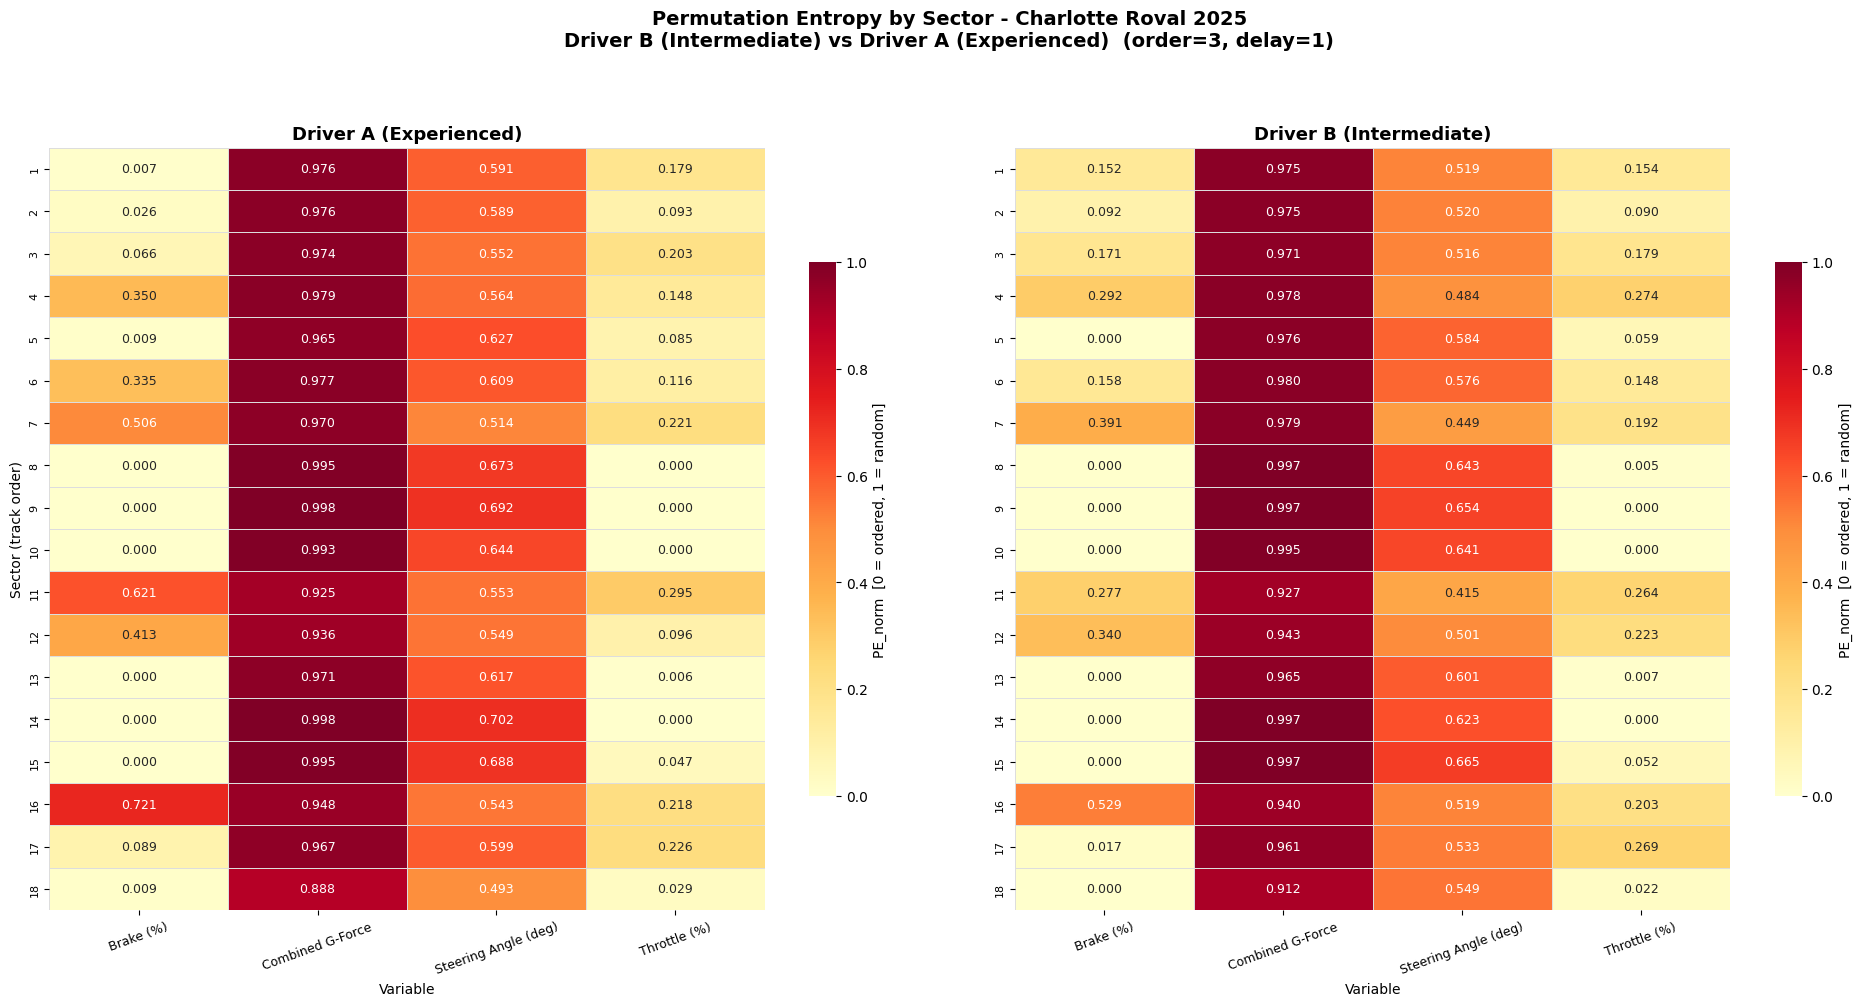

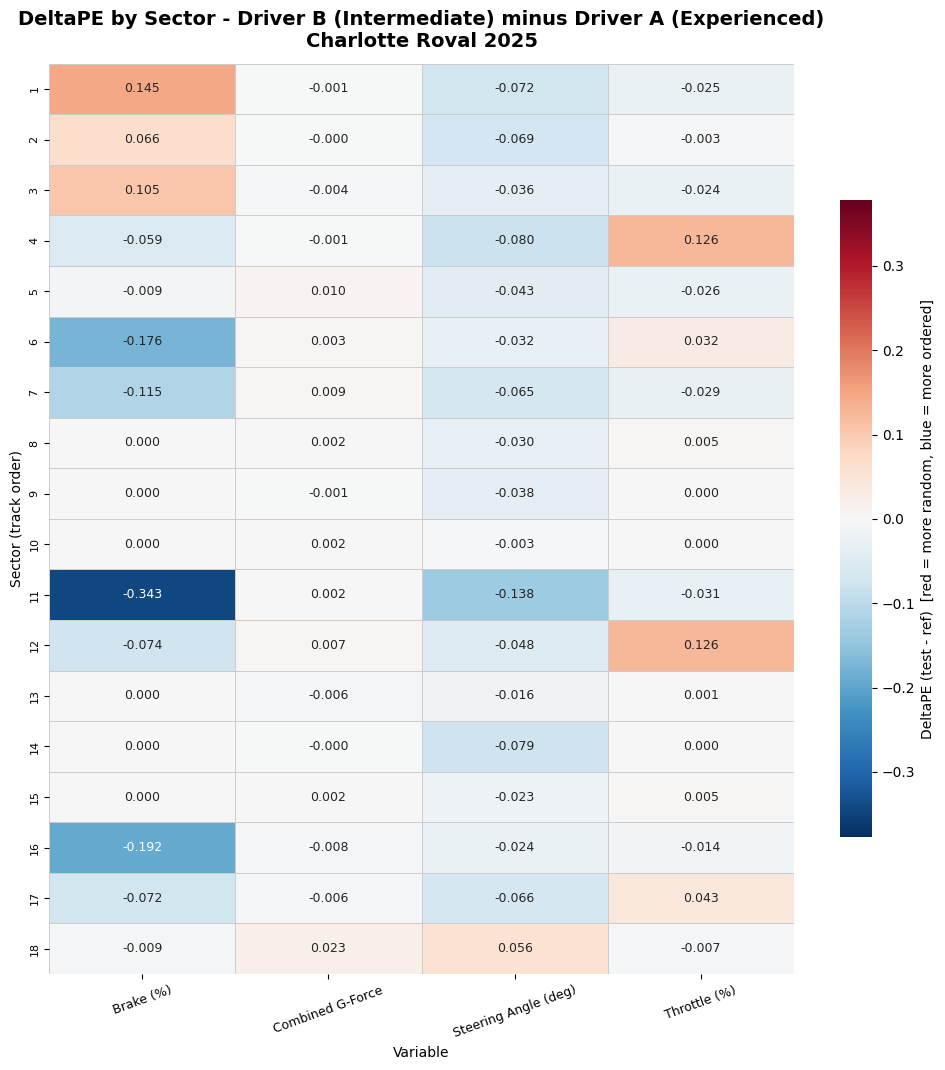

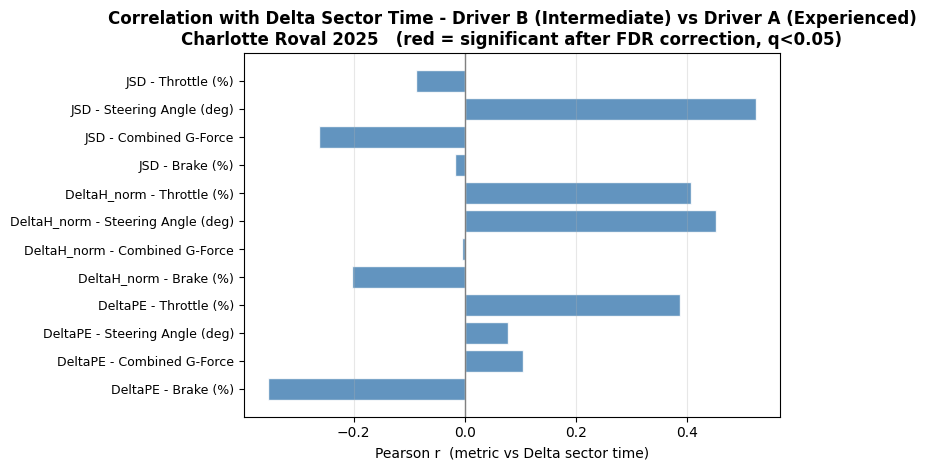

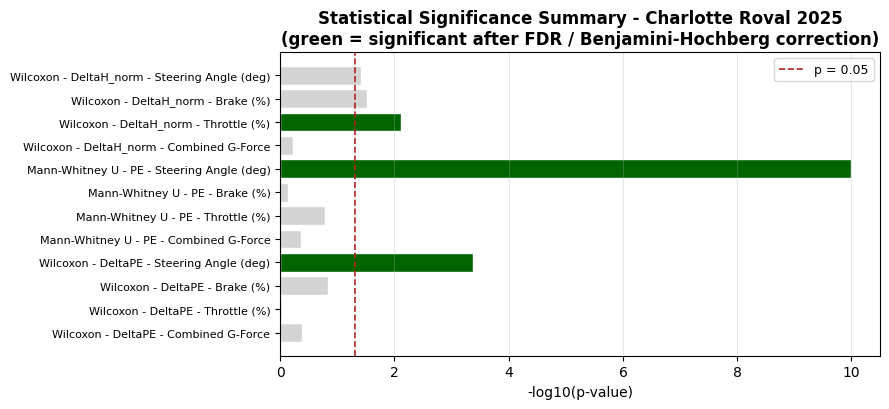

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\charlotte_roval_2025\B_vs_A_Tomaz_Rodrigo

  C_VS_B_MORSINALDO_TOMAZ  |  Charlotte Roval 2025
  Reference: Driver B (Intermediate)   |   Test: Driver C (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


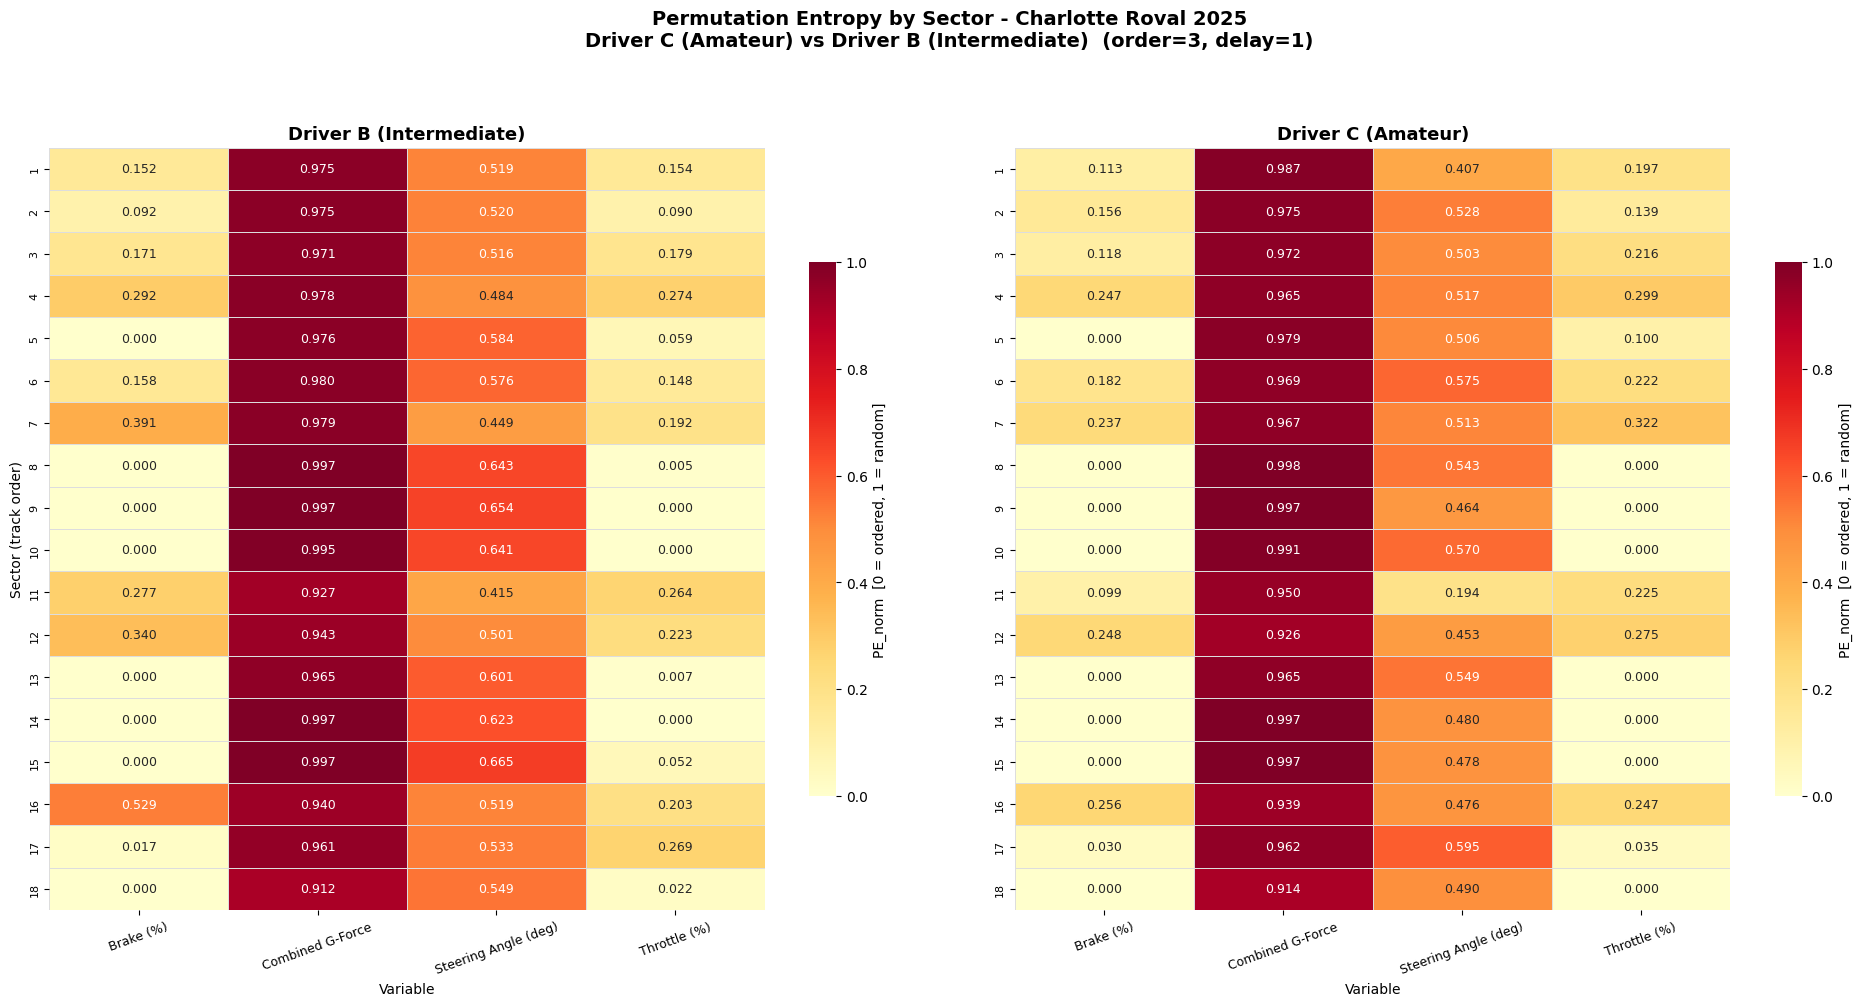

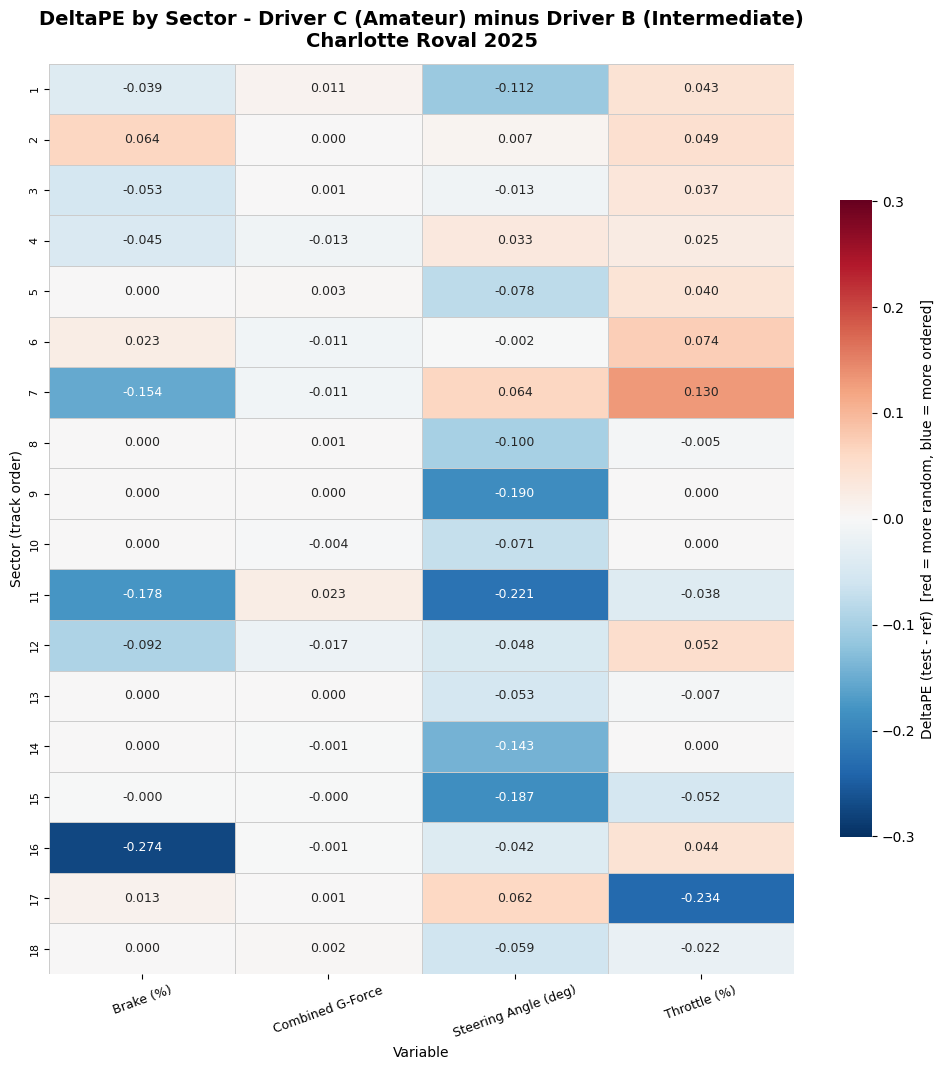

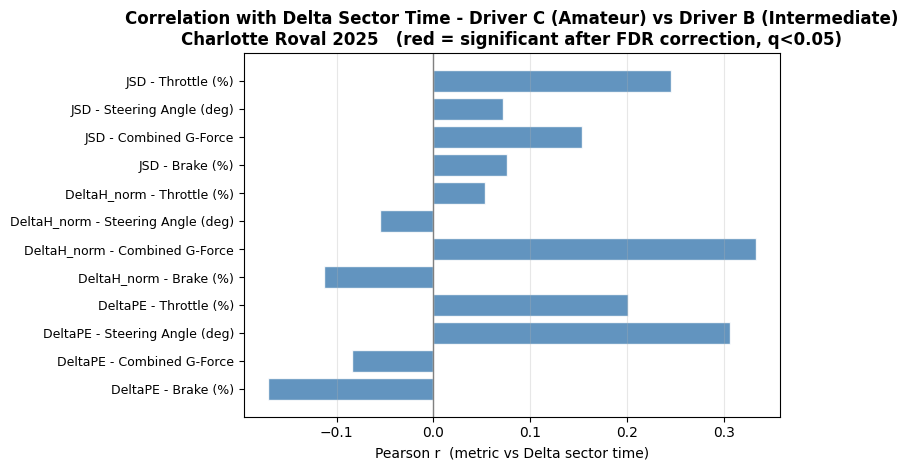

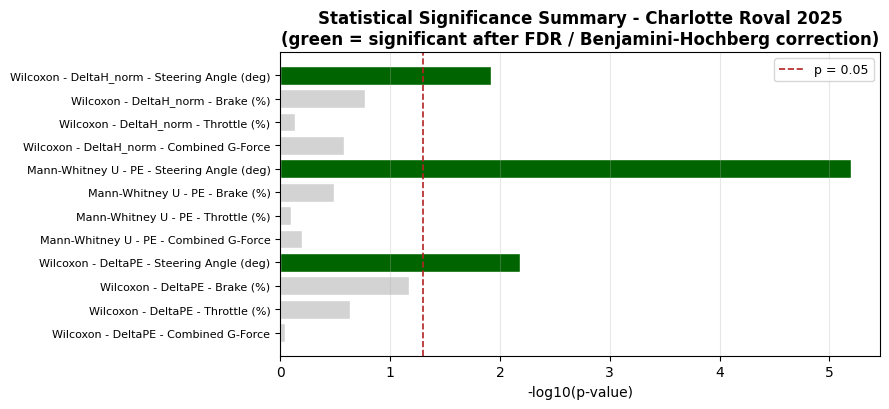

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\charlotte_roval_2025\C_vs_B_Morsinaldo_Tomaz

  D_VS_B_THALLYS_TOMAZ  |  Charlotte Roval 2025
  Reference: Driver B (Intermediate)   |   Test: Driver D (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


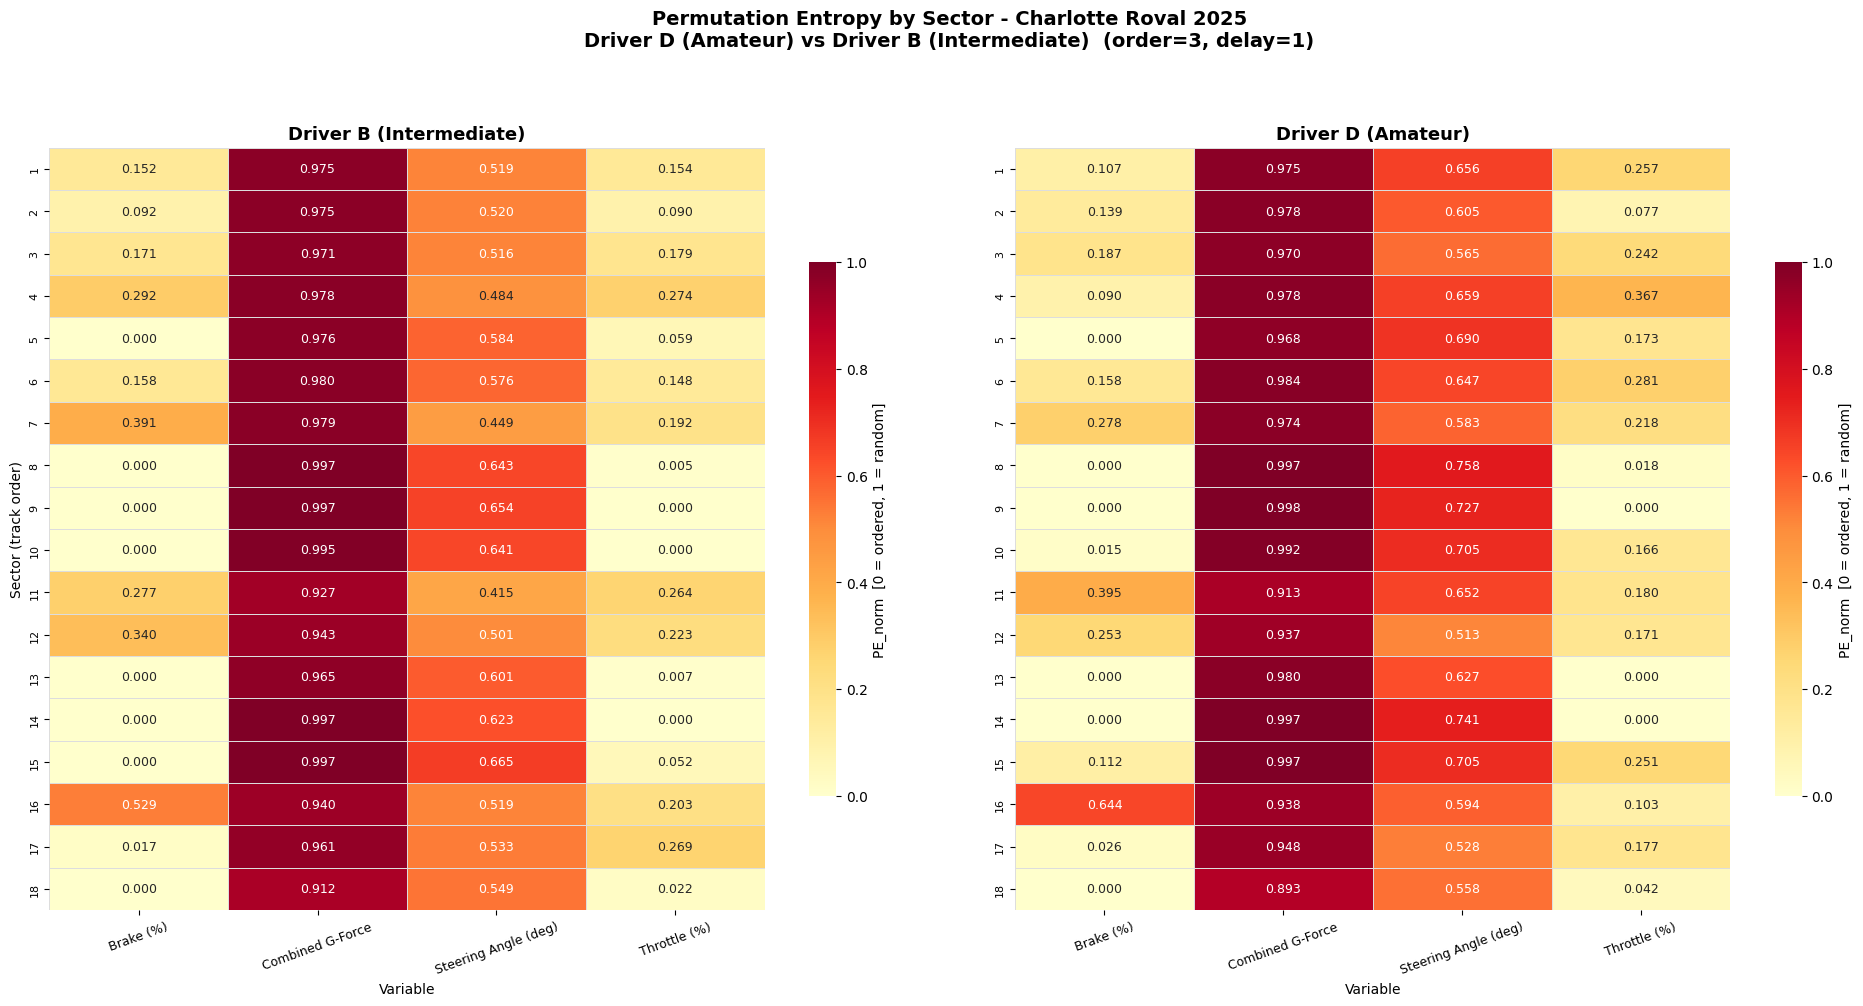

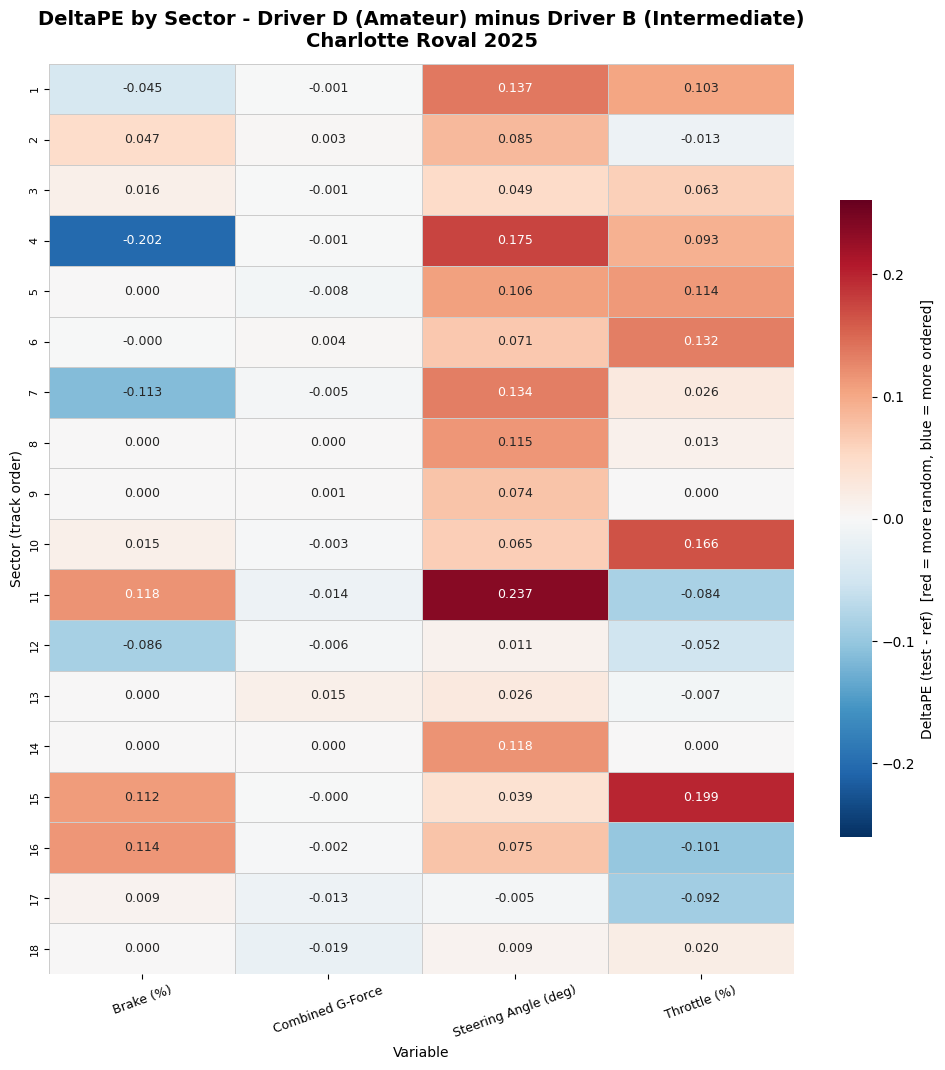

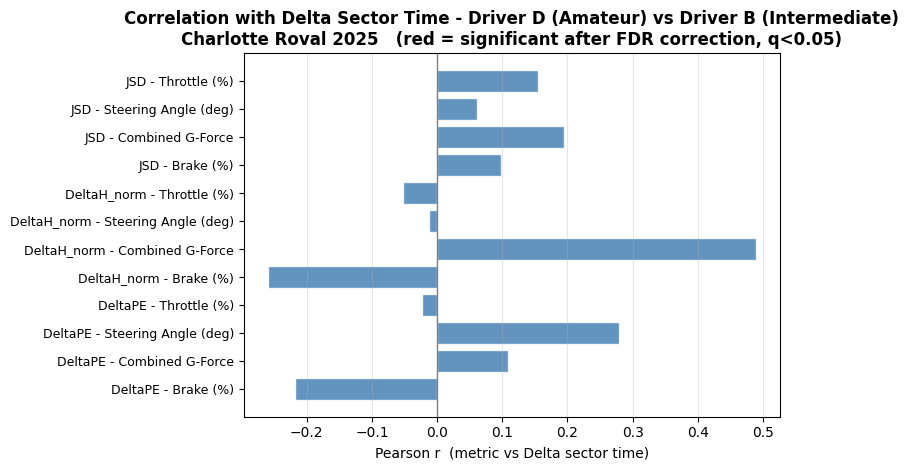

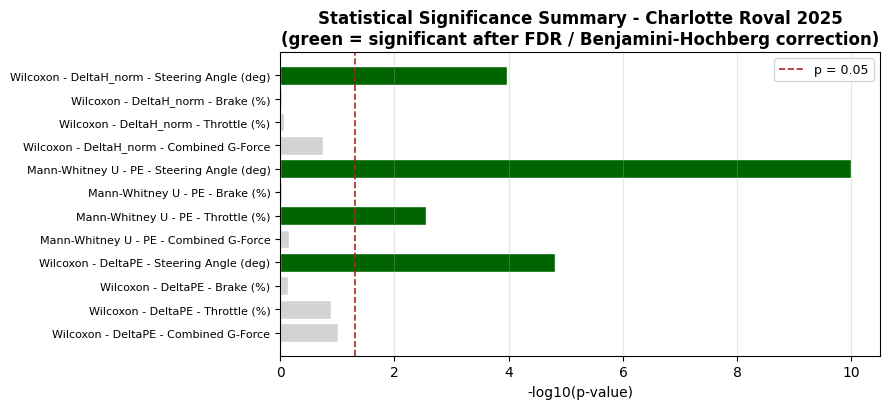

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\charlotte_roval_2025\D_vs_B_Thallys_Tomaz

  E_VS_B_IGOR_TOMAZ  |  Charlotte Roval 2025
  Reference: Driver B (Intermediate)   |   Test: Driver E (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


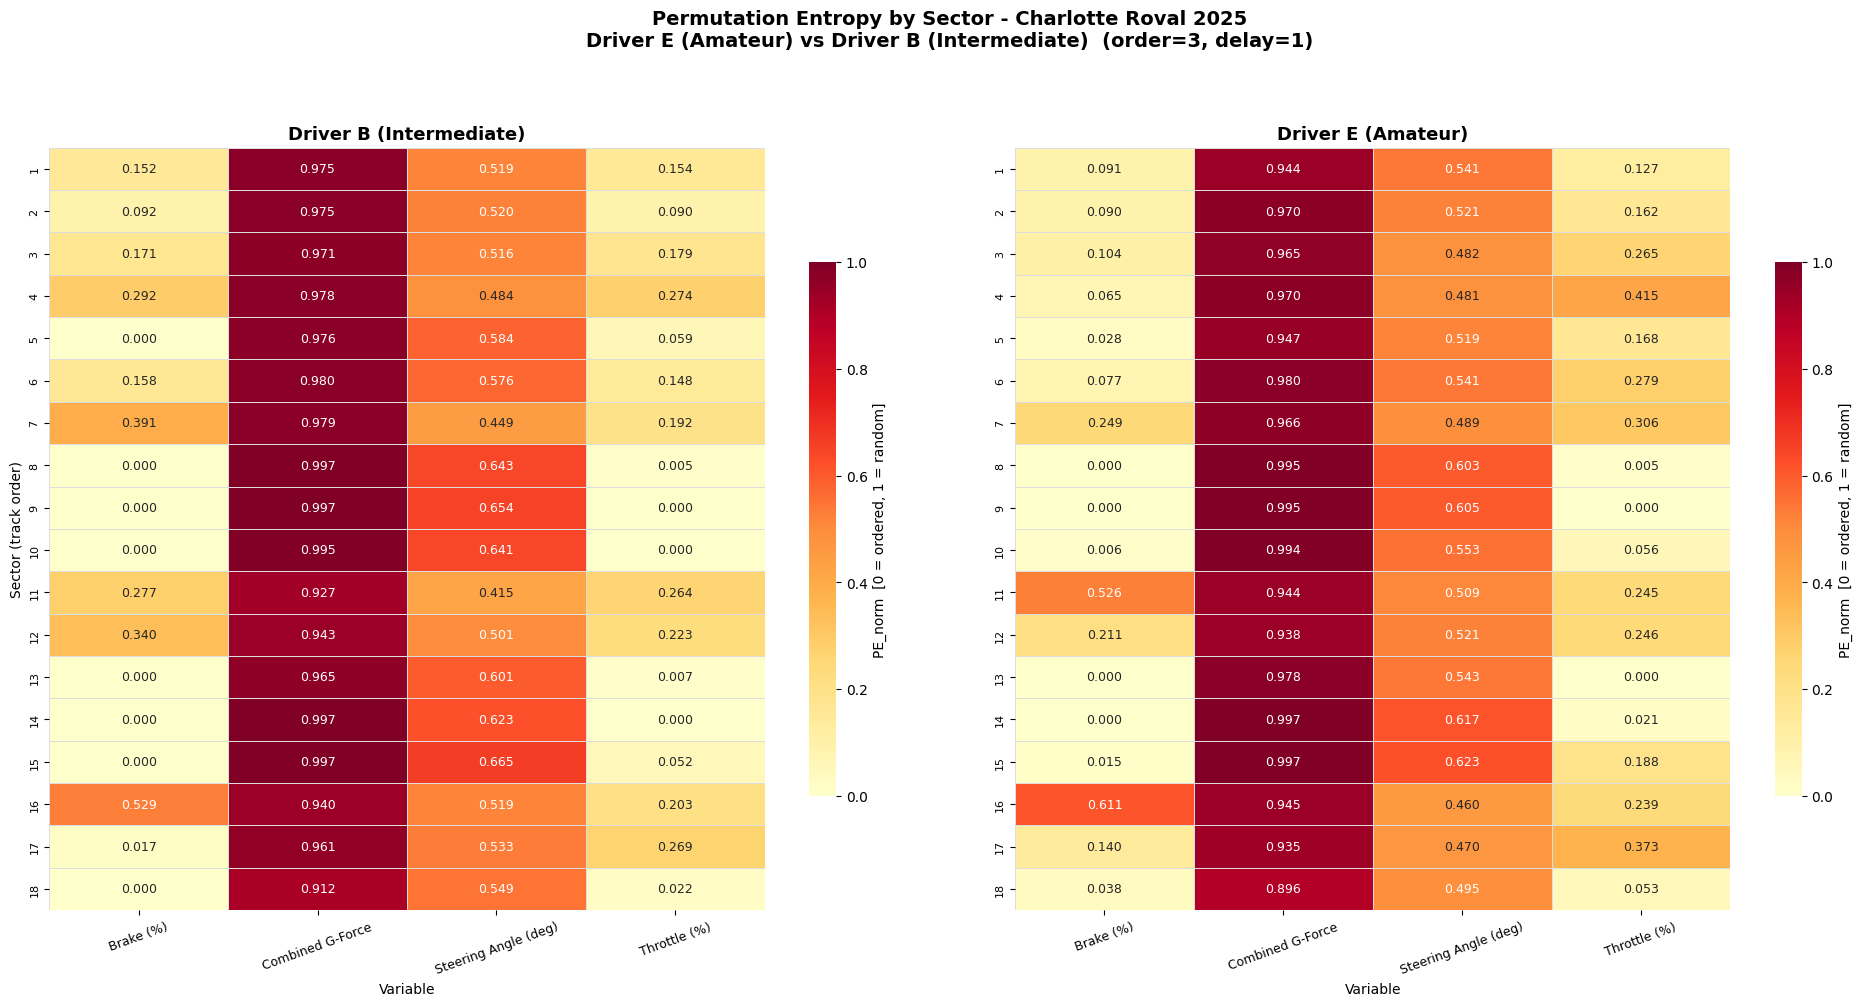

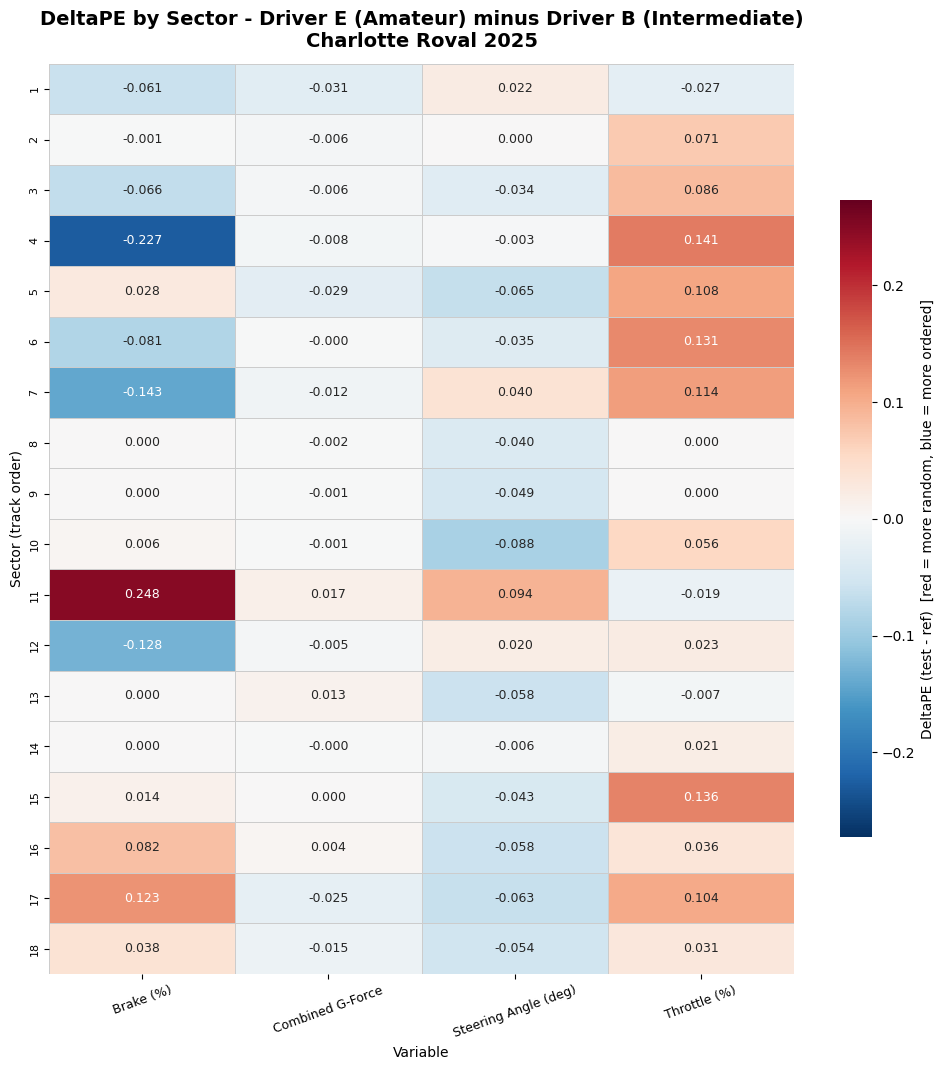

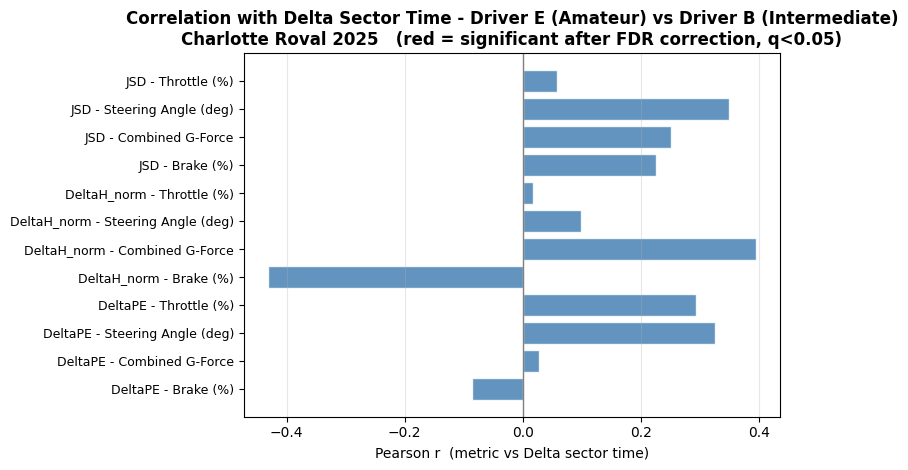

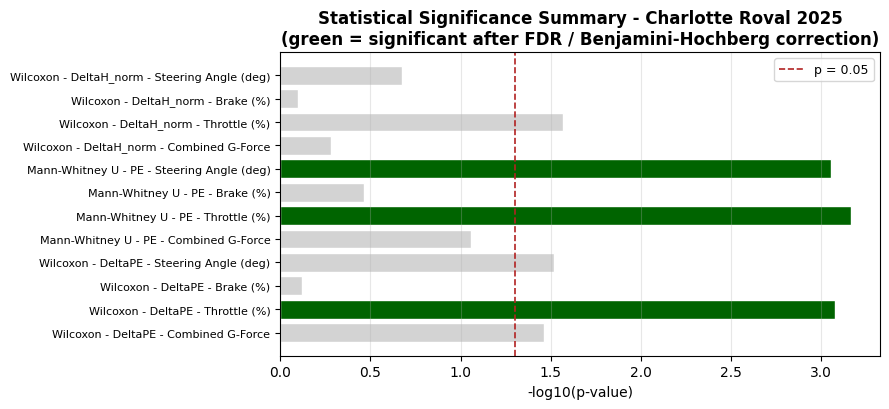

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\charlotte_roval_2025\E_vs_B_Igor_Tomaz

  F_VS_B_HILTON_TOMAZ  |  Charlotte Roval 2025
  Reference: Driver B (Intermediate)   |   Test: Driver F (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


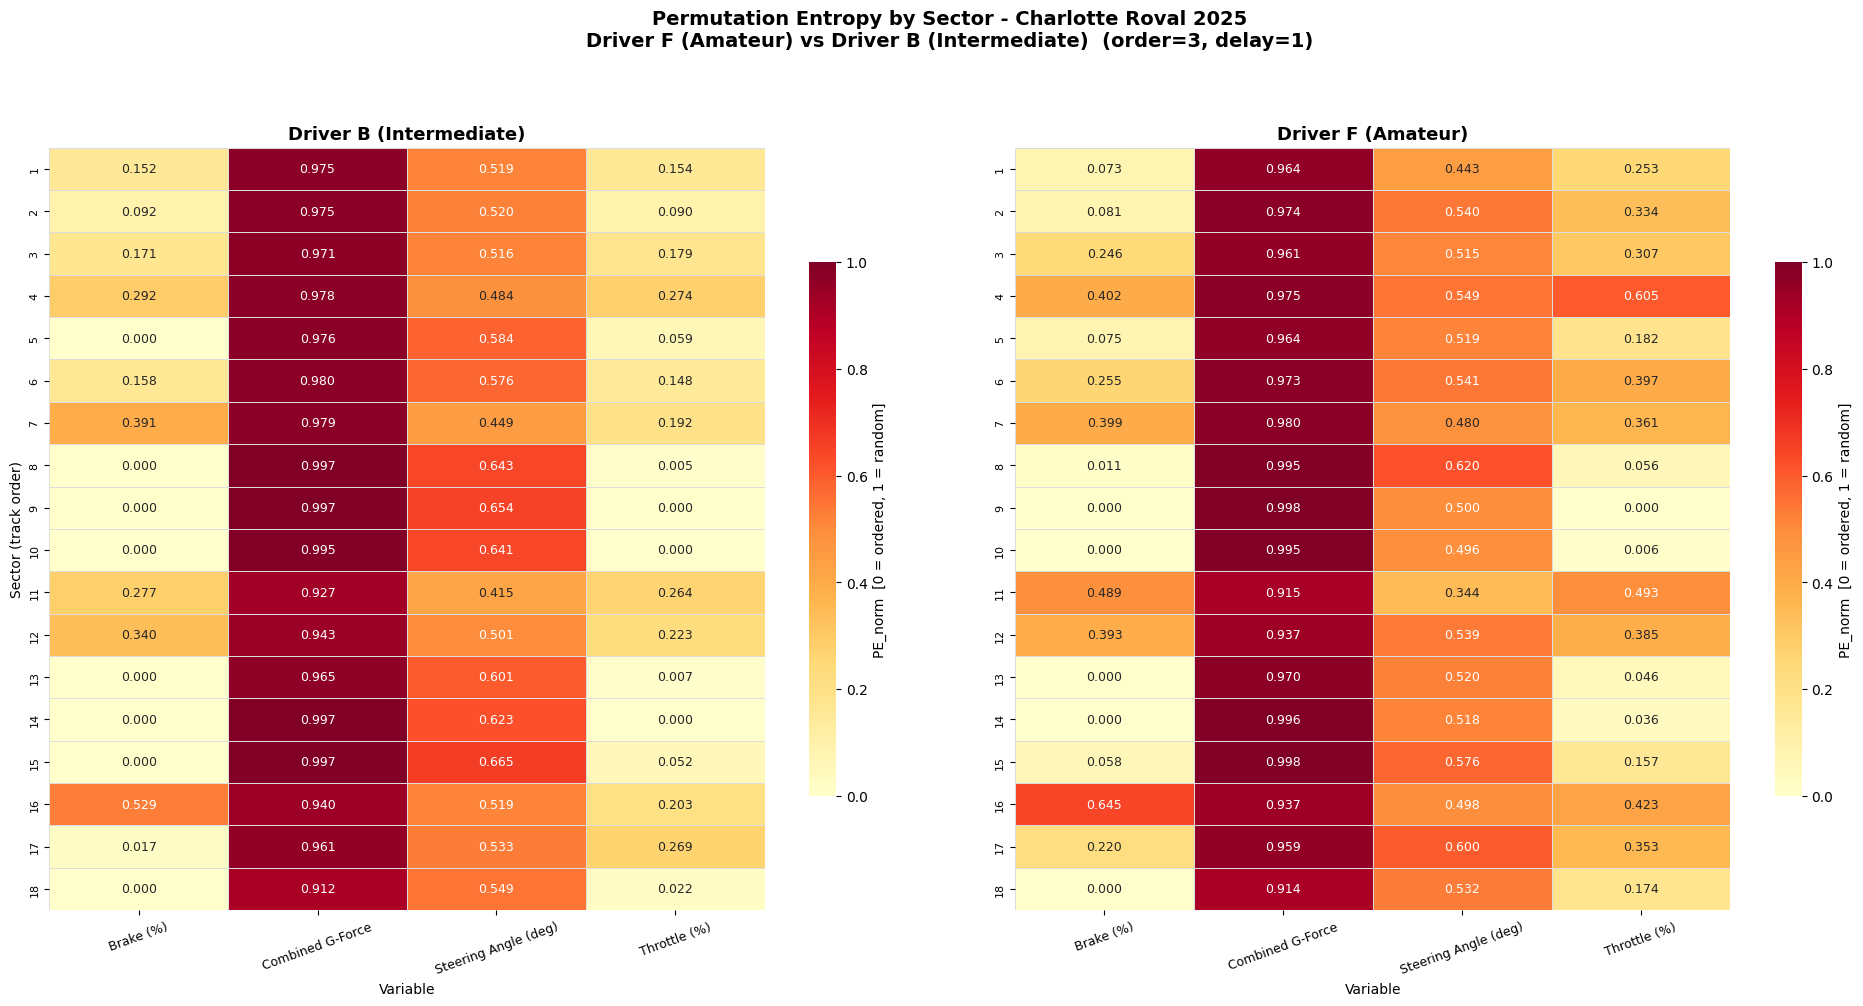

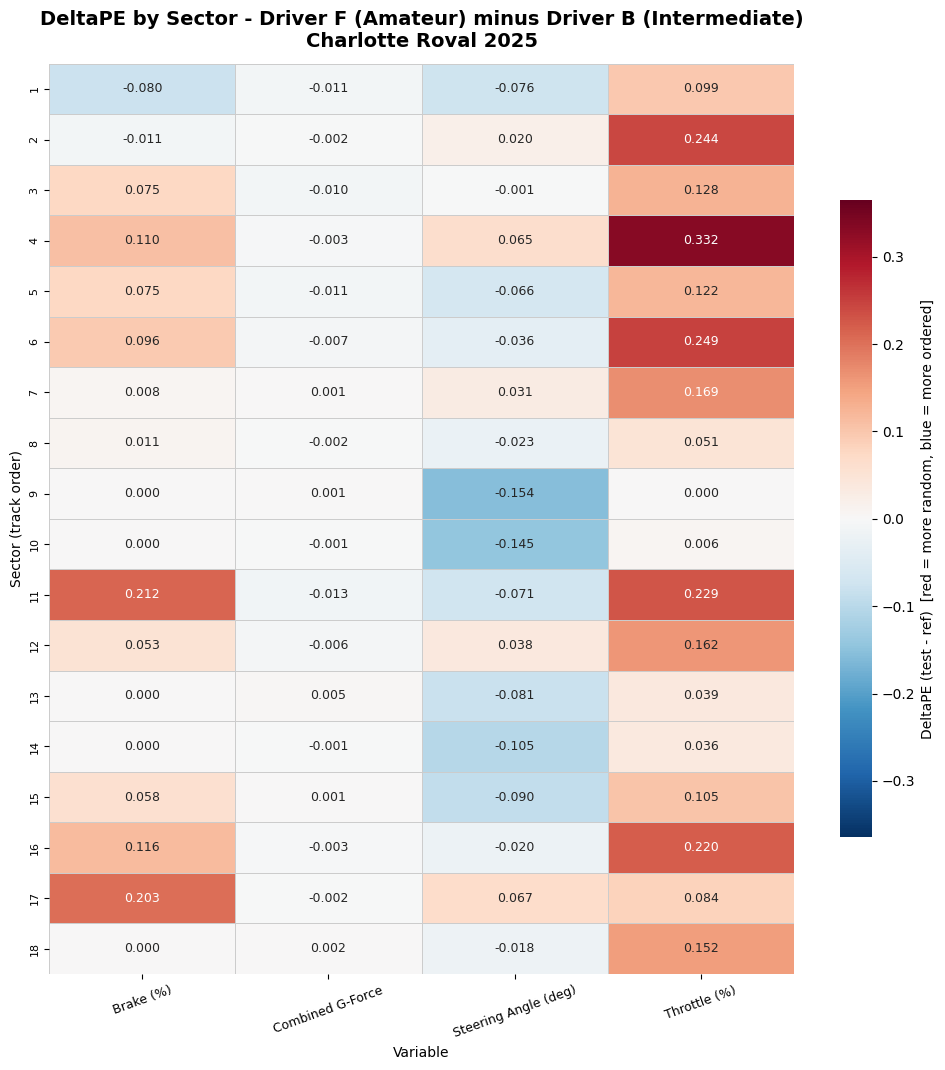

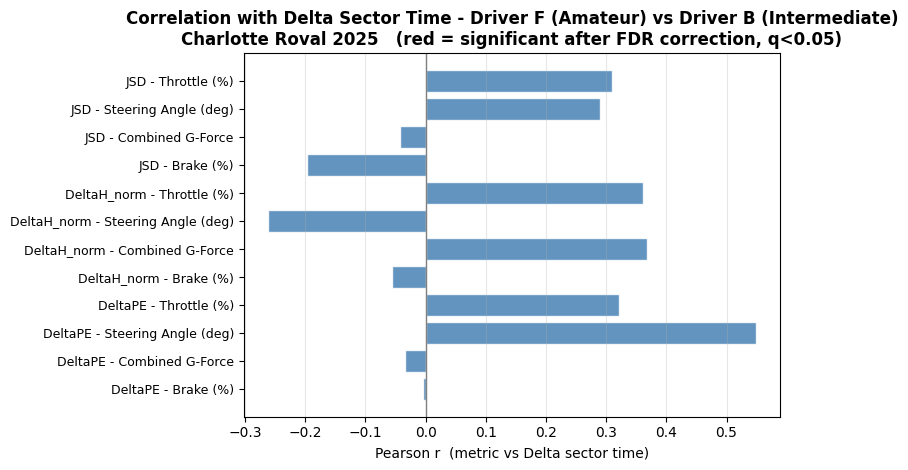

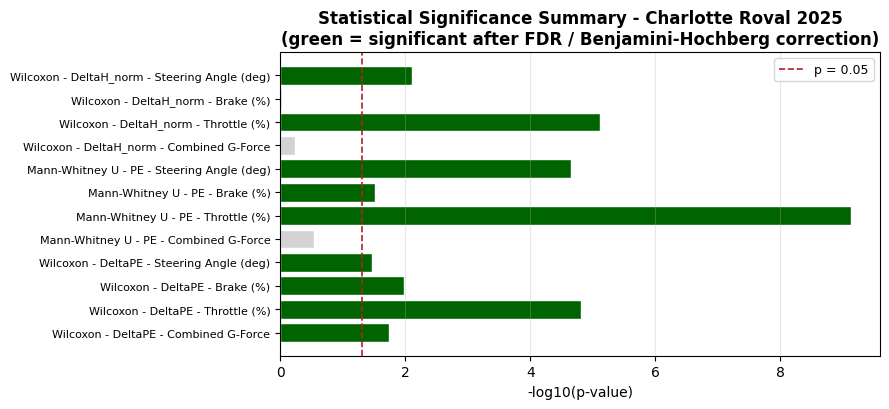

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\charlotte_roval_2025\F_vs_B_Hilton_Tomaz

  B_VS_A_TOMAZ_RODRIGO  |  Summit Point - Main Circuit
  Reference: Driver A (Experienced)   |   Test: Driver B (Intermediate)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


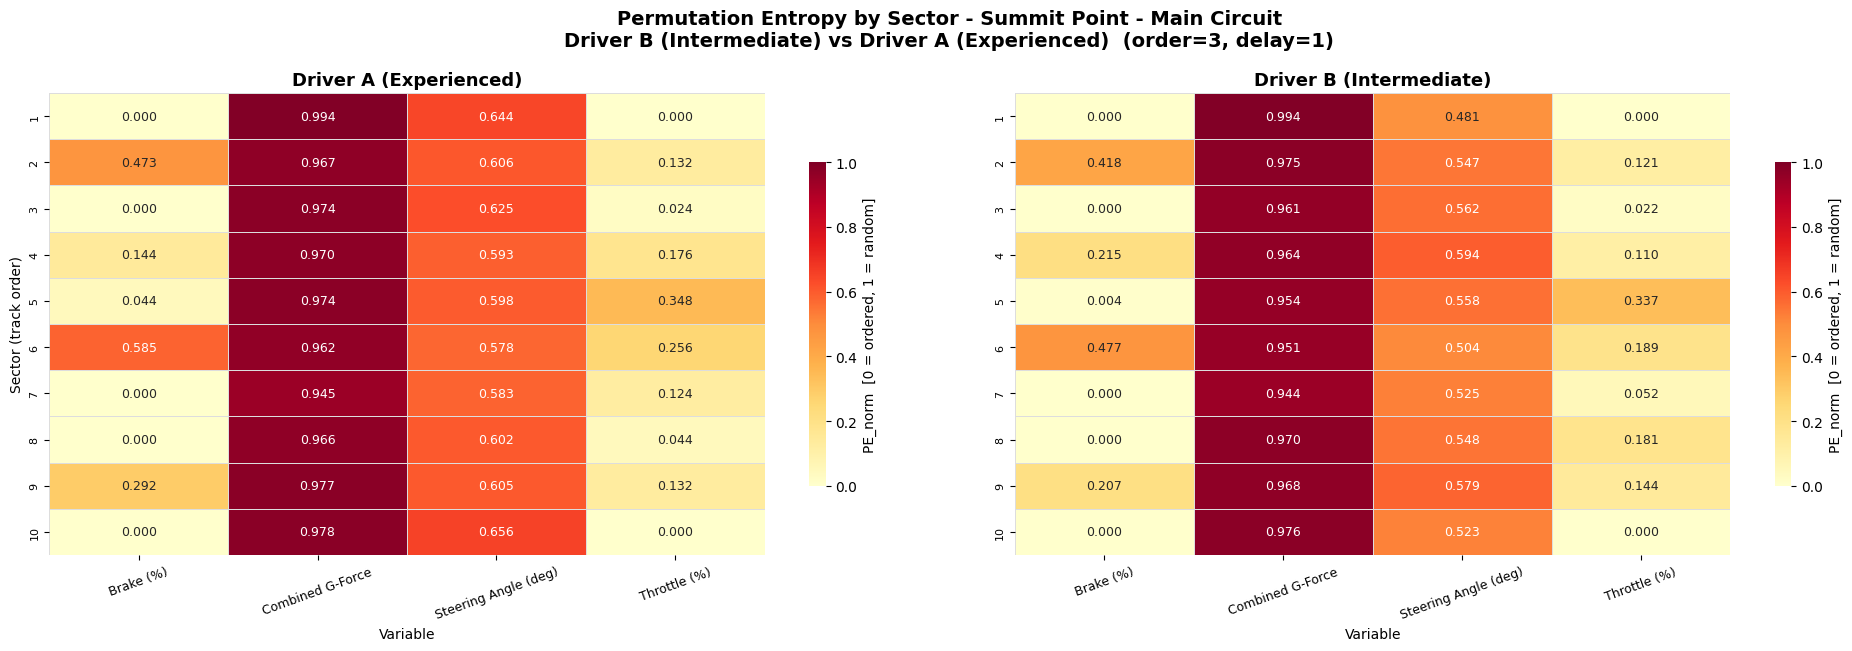

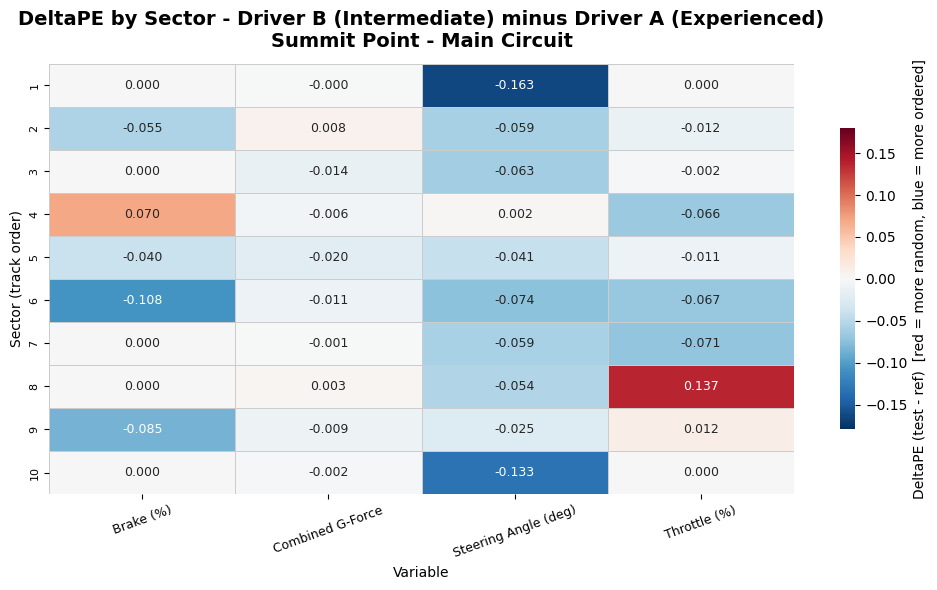

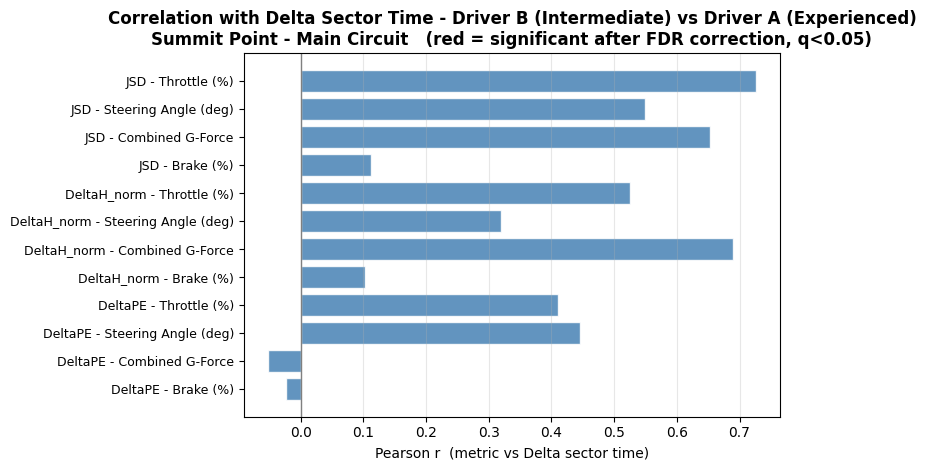

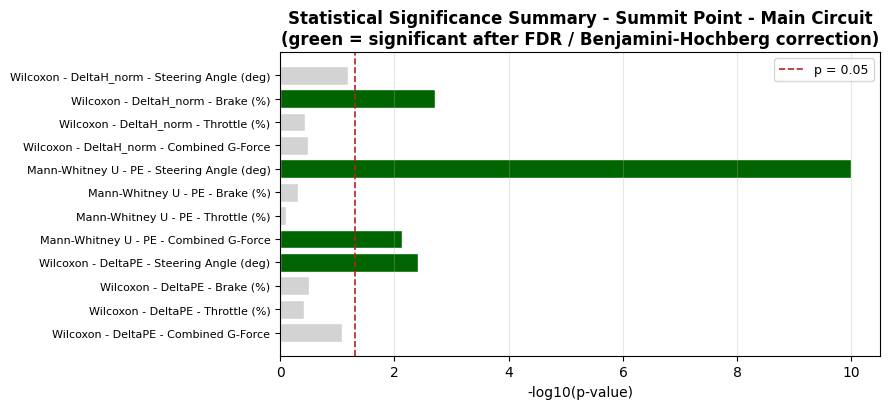

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\summit_point\B_vs_A_Tomaz_Rodrigo

  C_VS_B_MORSINALDO_TOMAZ  |  Summit Point - Main Circuit
  Reference: Driver B (Intermediate)   |   Test: Driver C (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


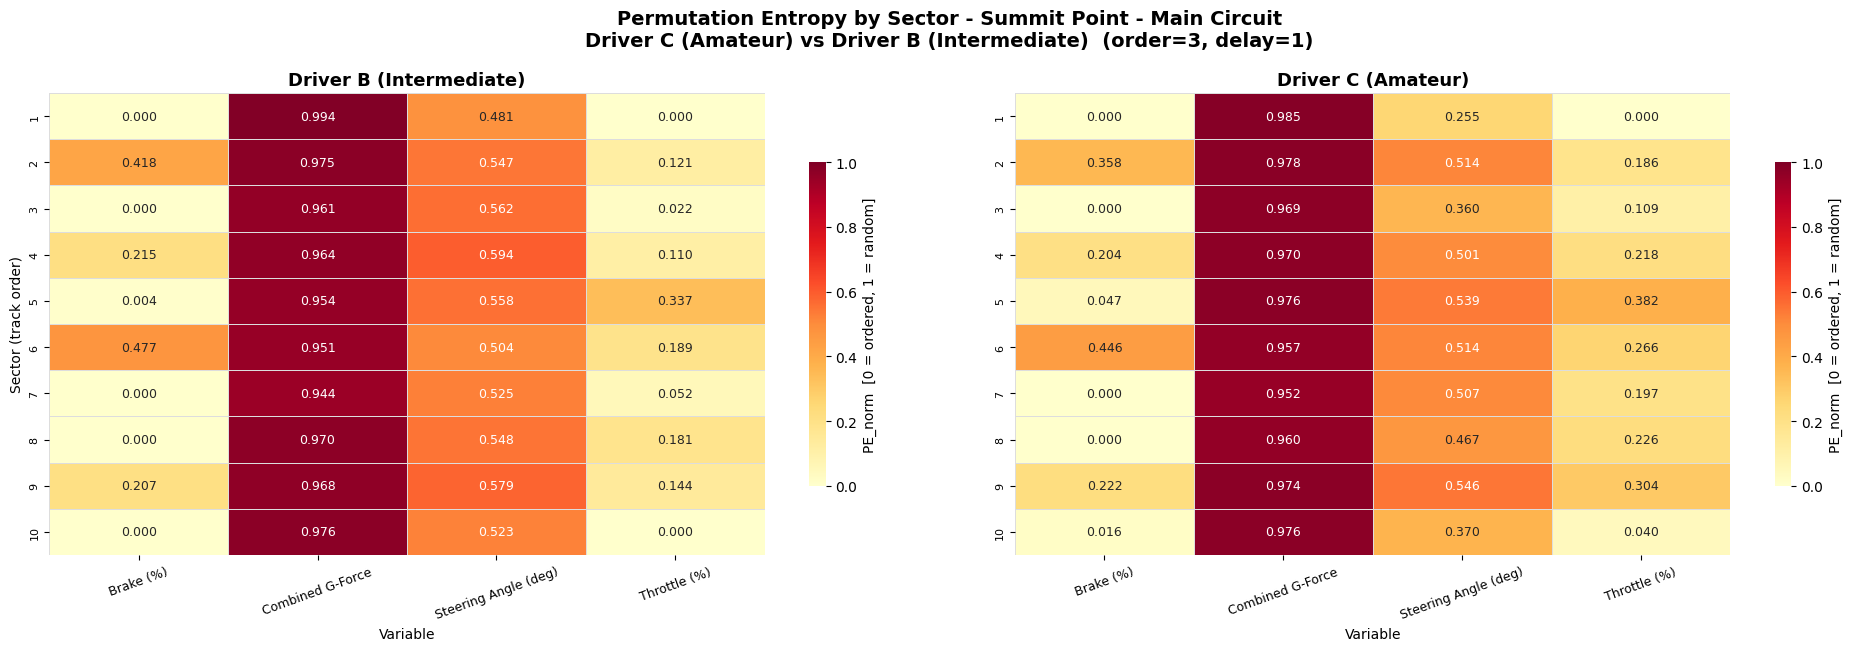

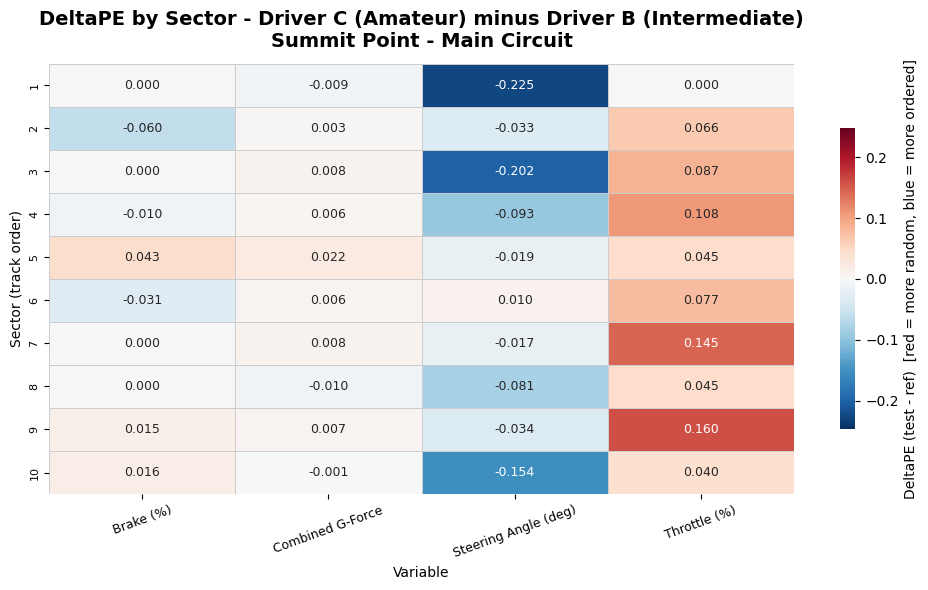

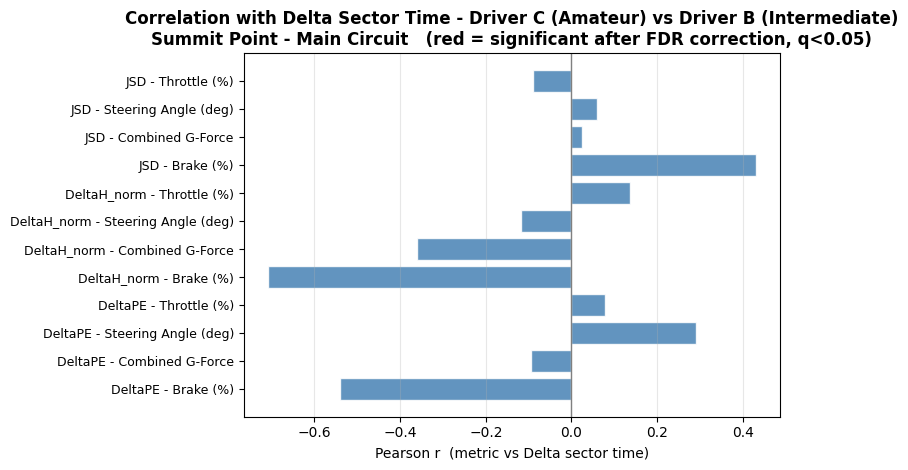

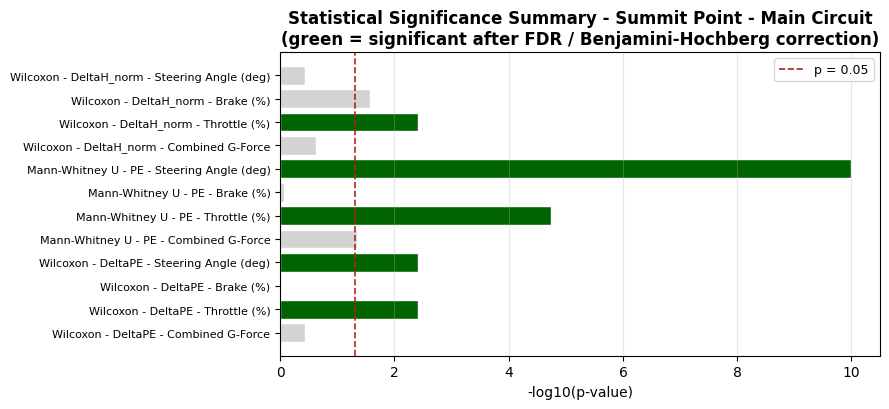

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\summit_point\C_vs_B_Morsinaldo_Tomaz

  D_VS_B_THALLYS_TOMAZ  |  Summit Point - Main Circuit
  Reference: Driver B (Intermediate)   |   Test: Driver D (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


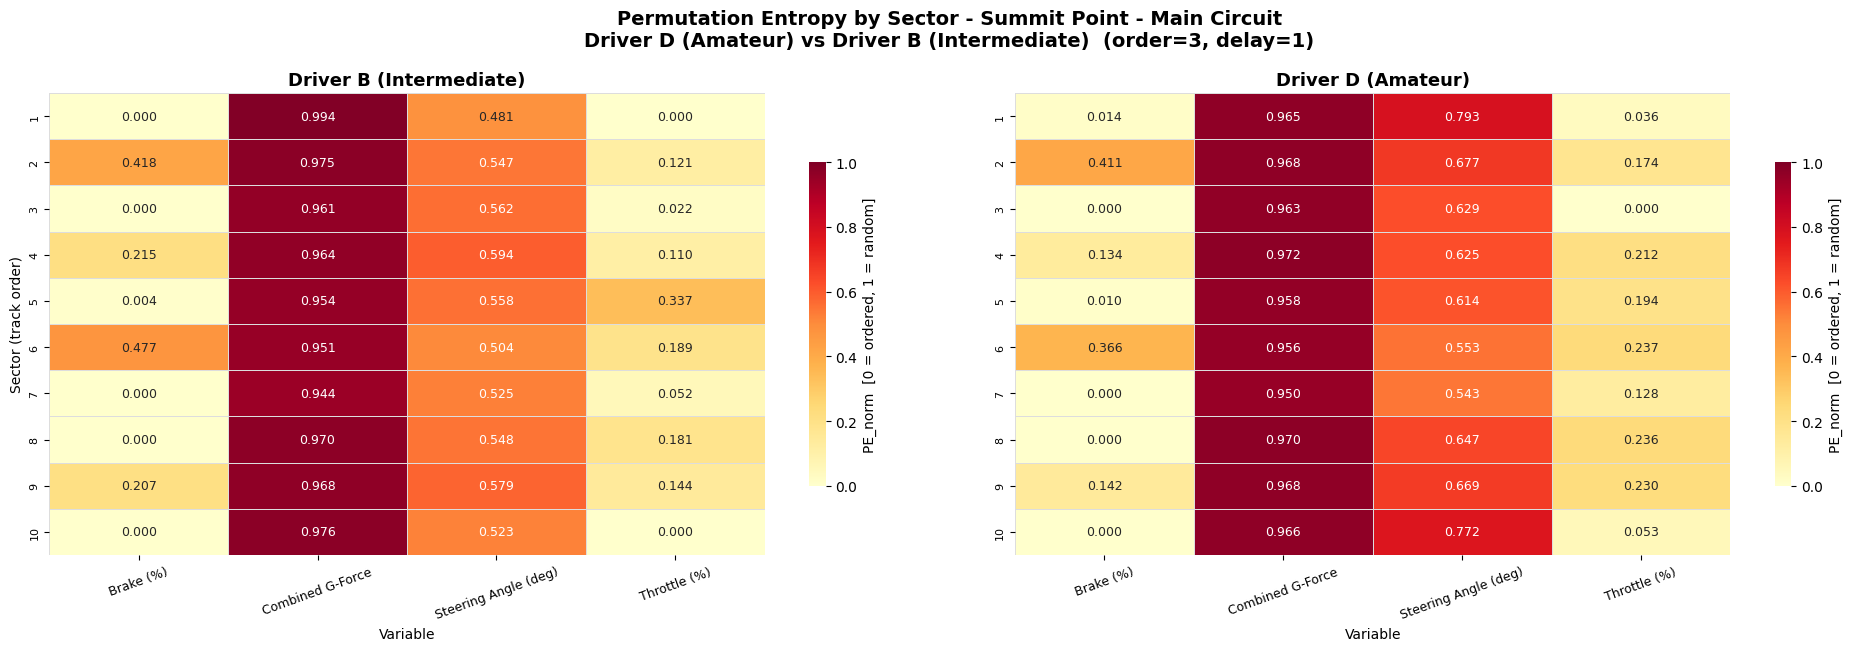

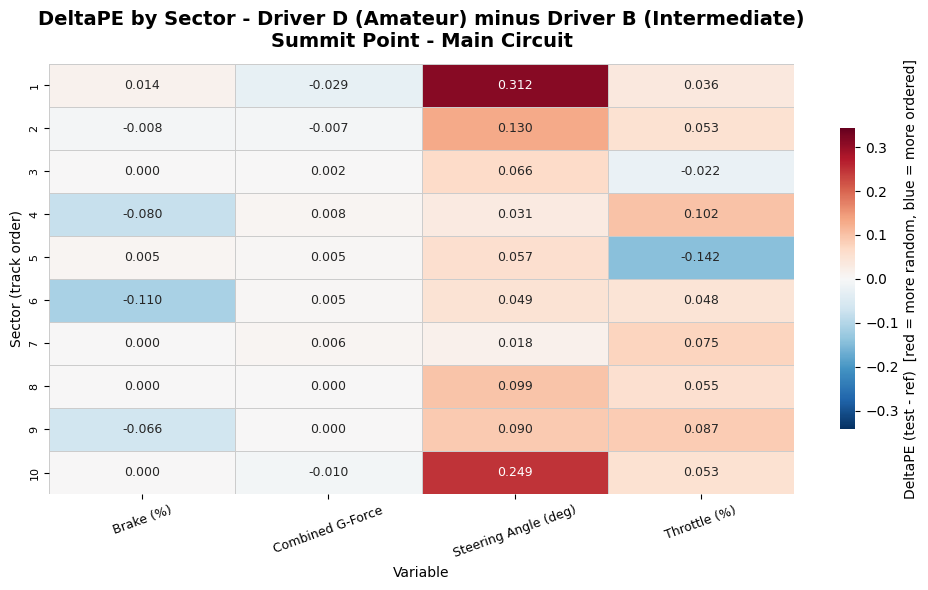

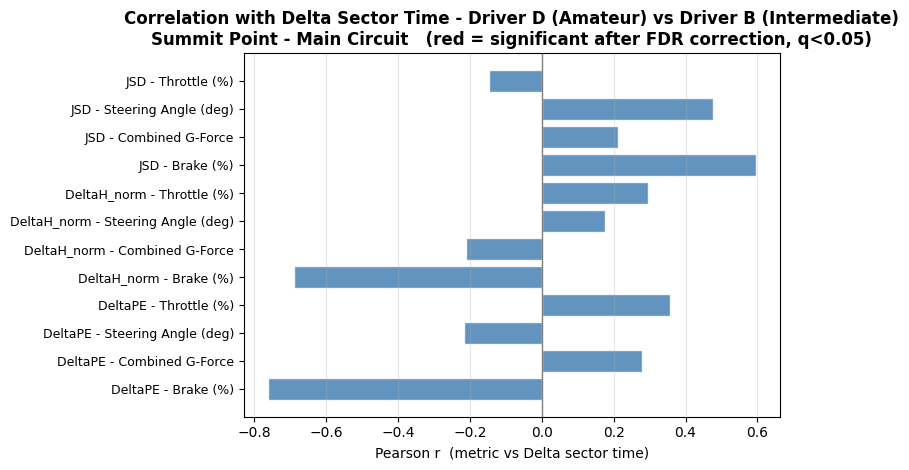

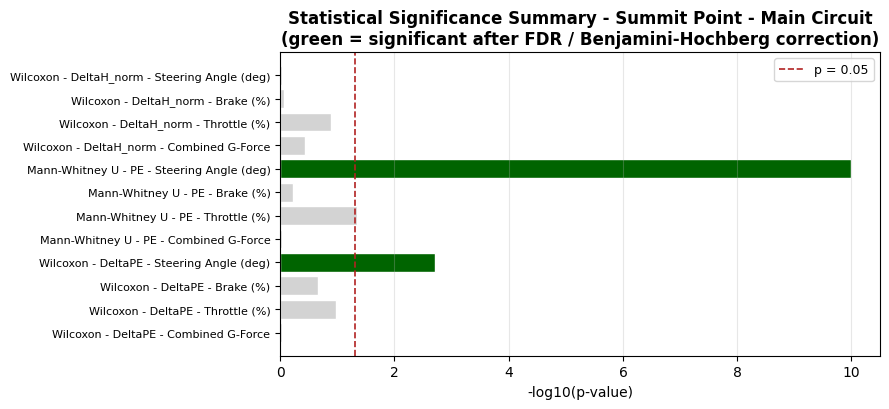

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\summit_point\D_vs_B_Thallys_Tomaz

  E_VS_B_IGOR_TOMAZ  |  Summit Point - Main Circuit
  Reference: Driver B (Intermediate)   |   Test: Driver E (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


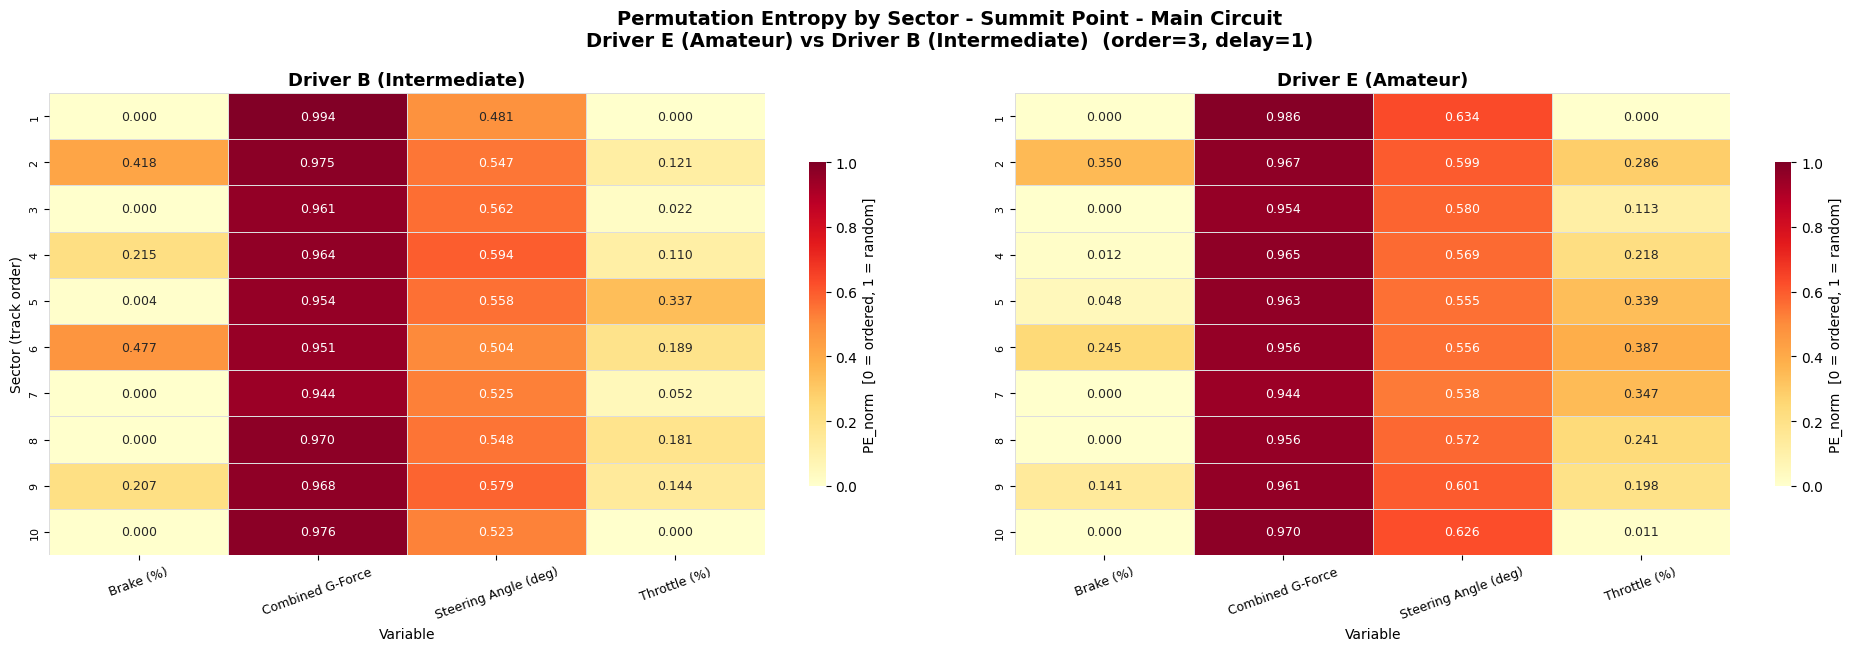

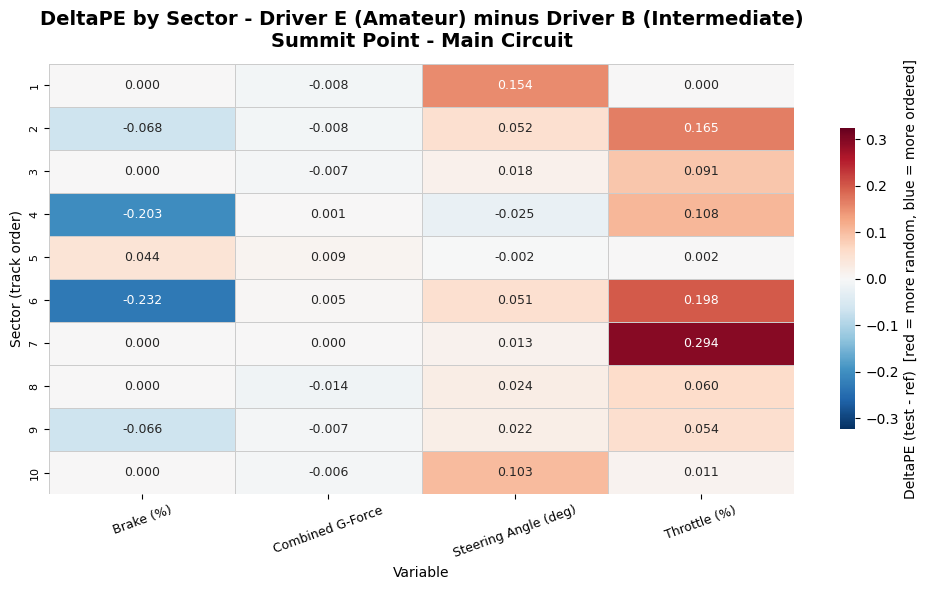

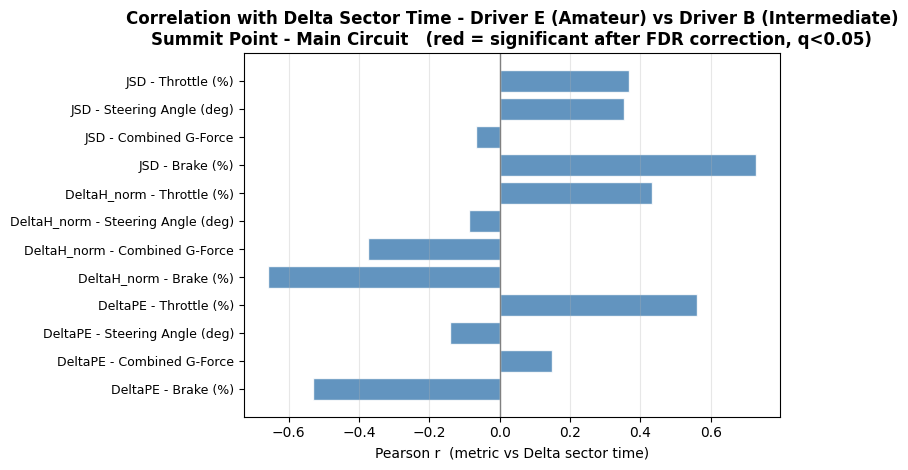

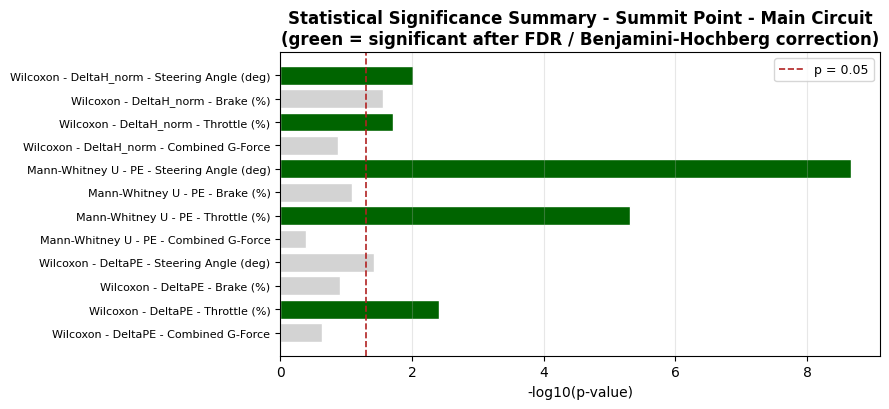

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\summit_point\E_vs_B_Igor_Tomaz

  F_VS_B_HILTON_TOMAZ  |  Summit Point - Main Circuit
  Reference: Driver B (Intermediate)   |   Test: Driver F (Amateur)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_17244\1117504887.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


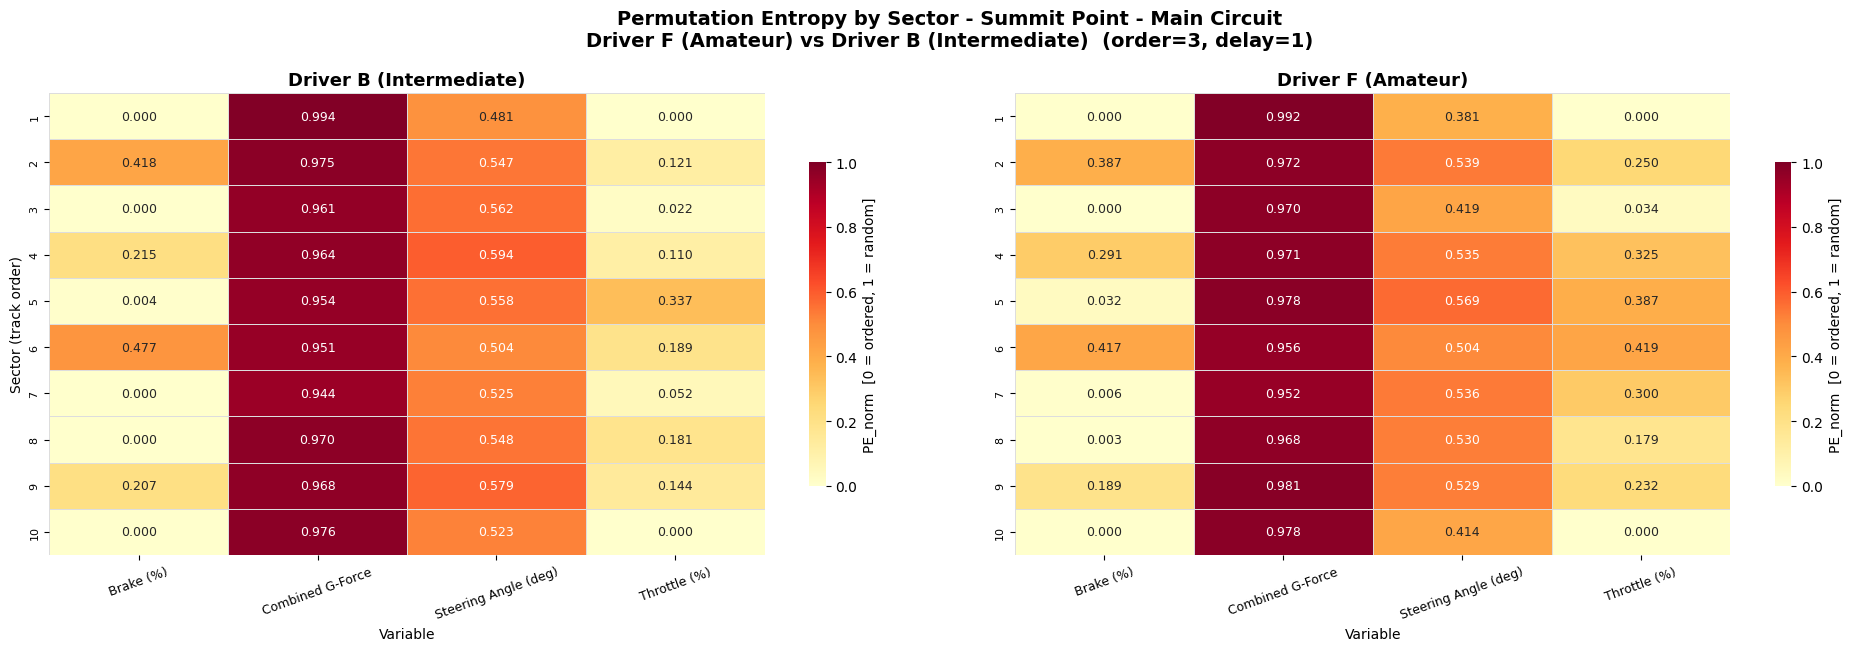

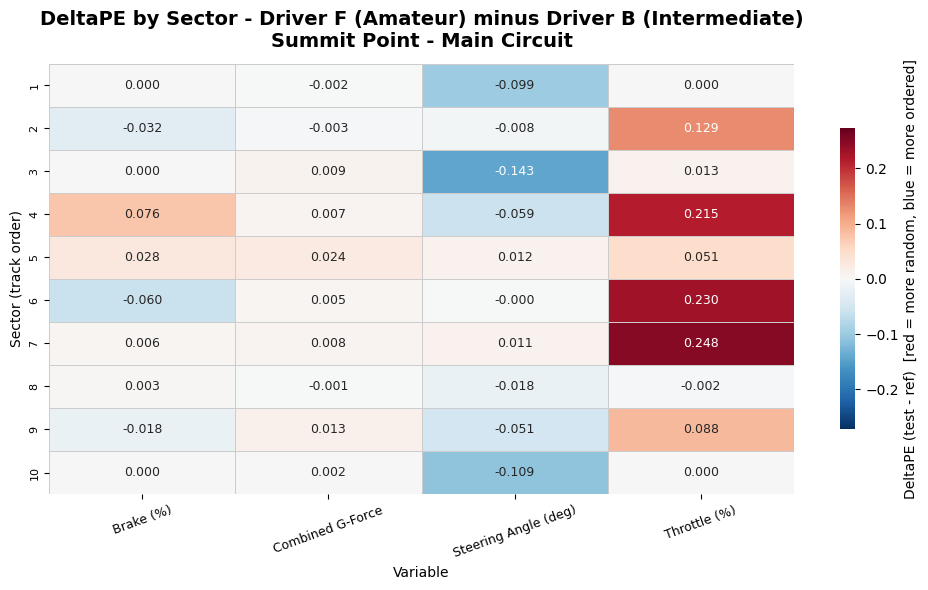

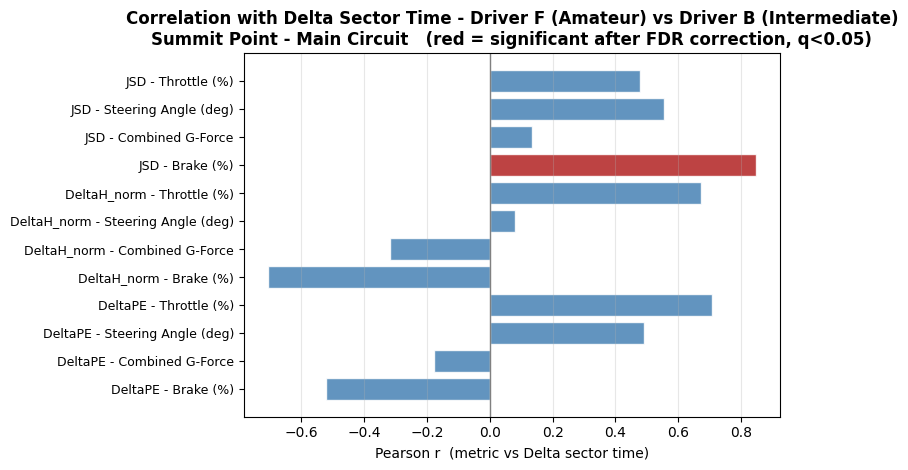

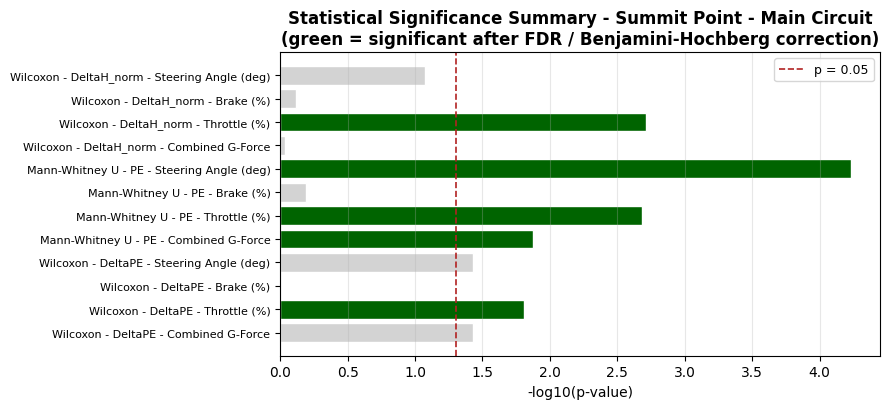

  Figures and tables saved to: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\summit_point\F_vs_B_Hilton_Tomaz

10 track x comparison combinations processed automatically.


In [11]:
for track_id in BATCH_TRACKS:
    for comparison in SKILL_COMPARISONS:
        result = run_skill_tier_analysis(track_id, comparison)
        if result is not None:
            ALL_RESULTS.append(result)

print(f"\n{len(ALL_RESULTS)} track x comparison combinations processed automatically.")

## 11. Combined summary tables (for Methods / Supplementary Material)

In [12]:
combined_sig_rows = []
for res in ALL_RESULTS:
    if res['df_sig'].empty:
        continue
    df = res['df_sig'].copy()
    df.insert(0, 'Comparison', res['comparison'])
    df.insert(0, 'Track', res['track_name'])
    combined_sig_rows.append(df)

df_sig_all = pd.concat(combined_sig_rows, ignore_index=True) if combined_sig_rows else pd.DataFrame()

combined_corr_rows = []
for res in ALL_RESULTS:
    if res['df_corr'].empty:
        continue
    df = res['df_corr'].copy()
    df.insert(0, 'Comparison', res['comparison'])
    df.insert(0, 'Track', res['track_name'])
    combined_corr_rows.append(df)

df_corr_all = pd.concat(combined_corr_rows, ignore_index=True) if combined_corr_rows else pd.DataFrame()

print("=" * 90)
print("  COMBINED STATISTICAL SIGNIFICANCE TABLE - ALL TRACKS x COMPARISONS")
print("=" * 90)
display(df_sig_all)

print("\n" + "=" * 90)
print("  COMBINED CORRELATION TABLE - DeltaPE / DeltaH_norm / JSD vs DELTA SECTOR TIME")
print("=" * 90)
display(df_corr_all)

csv_sig  = BATCH_SAVE_ROOT / "combined_significance_tests_all.csv"
csv_corr = BATCH_SAVE_ROOT / "combined_correlation_summary_all.csv"
df_sig_all.to_csv(csv_sig, index=False)
df_corr_all.to_csv(csv_corr, index=False)
print(f"\nCombined tables saved:\n  {csv_sig}\n  {csv_corr}")

  COMBINED STATISTICAL SIGNIFICANCE TABLE - ALL TRACKS x COMPARISONS


,Track,Comparison,Test,Metric,Variable,stat,p-value,effect_r,n,p-adj (FDR),sig (FDR)
0,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,"Wilcoxon (paired, by sector)",DeltaPE,Combined G-Force,66.0,0.417114,0.228070,18,0.575223,False
1,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,"Wilcoxon (paired, by sector)",DeltaPE,Throttle (%),58.0,0.934082,0.033333,15,0.934082,False
2,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,"Wilcoxon (paired, by sector)",DeltaPE,Brake (%),24.0,0.146484,-0.472527,13,0.285157,False
3,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,"Wilcoxon (paired, by sector)",DeltaPE,Steering Angle (deg),11.0,0.000420,-0.871345,18,0.002518,True
4,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,"Mann-Whitney U (unpaired, by lap)",PE,Combined G-Force,181767.0,0.431417,0.026026,648/576,0.575223,False
...,...,...,...,...,...,...,...,...,...,...,...
115,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,"Mann-Whitney U (unpaired, by lap)",PE,Steering Angle (deg),3175.0,0.000058,-0.411111,90/50,0.000697,True
116,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,"Wilcoxon (paired, by sector)",DeltaH_norm,Combined G-Force,26.0,0.921875,-0.054545,10,1.000000,False
117,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,"Wilcoxon (paired, by sector)",DeltaH_norm,Throttle (%),0.0,0.001953,1.000000,10,0.008271,True
118,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,"Wilcoxon (paired, by sector)",DeltaH_norm,Brake (%),24.0,0.769531,0.127273,10,0.923437,False



  COMBINED CORRELATION TABLE - DeltaPE / DeltaH_norm / JSD vs DELTA SECTOR TIME


,Track,Comparison,Metric,Variable,n_sectors,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_p_FDR,Pearson_sig_FDR
0,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,DeltaPE,Brake (%),18,-0.354032,0.149479,-0.593359,0.009438,0.358750,False
1,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,DeltaPE,Combined G-Force,18,0.105635,0.676556,0.141383,0.575754,0.911853,False
2,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,DeltaPE,Steering Angle (deg),18,0.077496,0.759877,0.011352,0.964342,0.911853,False
3,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,DeltaPE,Throttle (%),18,0.387982,0.111620,0.313341,0.205465,0.334861,False
4,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,DeltaH_norm,Brake (%),18,-0.202373,0.420624,-0.151703,0.547901,0.721070,False
...,...,...,...,...,...,...,...,...,...,...,...
115,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,DeltaH_norm,Throttle (%),10,0.674167,0.032527,0.587879,0.073878,0.097581,False
116,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,JSD,Brake (%),10,0.846714,0.001999,0.551515,0.098401,0.023986,True
117,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,JSD,Combined G-Force,10,0.134445,0.711161,-0.042424,0.907364,0.775812,False
118,Summit Point - Main Circuit,F_vs_B_Hilton_Tomaz,JSD,Steering Angle (deg),10,0.555538,0.095465,0.563636,0.089724,0.229115,False



Combined tables saved:
  C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\combined_significance_tests_all.csv
  C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\combined_correlation_summary_all.csv


In [13]:
print("df_sig_all vazio?", df_sig_all.empty)
print("Testes únicos:", df_sig_all['Test'].unique())
print("Métricas únicas:", df_sig_all['Metric'].unique())
print("Comparações únicas:", df_sig_all['Comparison'].unique())
print("Tracks únicos:", df_sig_all['Track'].unique())

df_wil_check = df_sig_all[(df_sig_all['Test'] == 'Wilcoxon (paired, by sector)') &
                           (df_sig_all['Metric'] == 'DeltaPE')]
print("\nLinhas Wilcoxon/DeltaPE:", len(df_wil_check))
display(df_wil_check[['Track','Comparison','Variable','p-value','n','sig (FDR)']])

df_sig_all vazio? False
Testes únicos: ['Wilcoxon (paired, by sector)' 'Mann-Whitney U (unpaired, by lap)']
Métricas únicas: ['DeltaPE' 'PE' 'DeltaH_norm']
Comparações únicas: ['B_vs_A_Tomaz_Rodrigo' 'C_vs_B_Morsinaldo_Tomaz' 'D_vs_B_Thallys_Tomaz'
 'E_vs_B_Igor_Tomaz' 'F_vs_B_Hilton_Tomaz']
Tracks únicos: ['Charlotte Roval 2025' 'Summit Point - Main Circuit']

Linhas Wilcoxon/DeltaPE: 40


,Track,Comparison,Variable,p-value,n,sig (FDR)
0,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,Combined G-Force,0.417114,18,False
1,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,Throttle (%),0.934082,15,False
2,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,Brake (%),0.146484,13,False
3,Charlotte Roval 2025,B_vs_A_Tomaz_Rodrigo,Steering Angle (deg),0.000420,18,True
12,Charlotte Roval 2025,C_vs_B_Morsinaldo_Tomaz,Combined G-Force,0.898575,18,False
13,Charlotte Roval 2025,C_vs_B_Morsinaldo_Tomaz,Throttle (%),0.229309,15,False
14,Charlotte Roval 2025,C_vs_B_Morsinaldo_Tomaz,Brake (%),0.067383,11,False
15,Charlotte Roval 2025,C_vs_B_Morsinaldo_Tomaz,Steering Angle (deg),0.006577,18,True
24,Charlotte Roval 2025,D_vs_B_Thallys_Tomaz,Combined G-Force,0.098740,18,False
25,Charlotte Roval 2025,D_vs_B_Thallys_Tomaz,Throttle (%),0.129730,16,False


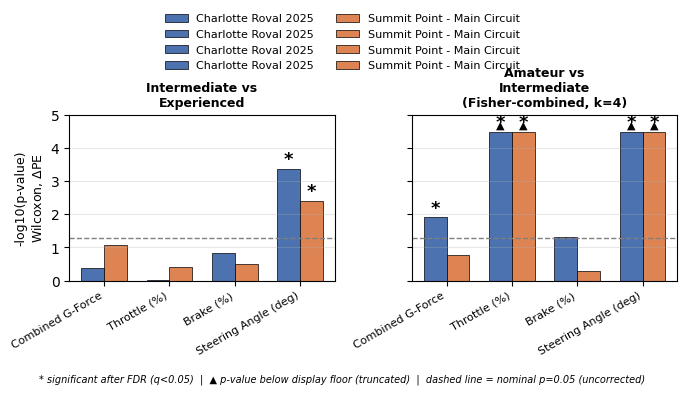

In [25]:
from scipy.stats import combine_pvalues

# ── Mapeamento correto grupo -> comparações reais do seu df_sig_all ──
GROUP_DEFINITIONS = {
    'intermediate_vs_experienced': ['B_vs_A_Tomaz_Rodrigo'],
    'amateur_vs_intermediate': ['C_vs_B_Morsinaldo_Tomaz', 'D_vs_B_Thallys_Tomaz',
                                 'E_vs_B_Igor_Tomaz', 'F_vs_B_Hilton_Tomaz'],
}
group_labels = {
    'intermediate_vs_experienced': 'Intermediate vs\nExperienced',
    'amateur_vs_intermediate': 'Amateur vs\nIntermediate\n(Fisher-combined, k=4)',
}

metric_to_plot = 'DeltaPE'
test_name = 'Wilcoxon (paired, by sector)'
variables_order = [label for _, label in VARIABLES_ENTROPY]
tracks = sorted(df_sig_all['Track'].unique())

df_wil = df_sig_all[(df_sig_all['Test'] == test_name) &
                     (df_sig_all['Metric'] == metric_to_plot)].copy()

# ── Combina p-valores dentro de cada grupo (Fisher) ──
records = []
for group_id, comp_ids in GROUP_DEFINITIONS.items():
    for track_name in tracks:
        for var in variables_order:
            sub = df_wil[(df_wil['Comparison'].isin(comp_ids)) &
                         (df_wil['Track'] == track_name) &
                         (df_wil['Variable'] == var)]
            pvals = sub['p-value'].dropna().values
            if len(pvals) == 0:
                p_comb = np.nan
            elif len(pvals) == 1:
                p_comb = pvals[0]                 # só 1 comparação -> nada a combinar
            else:
                _, p_comb = combine_pvalues(pvals, method='fisher')
            records.append({'Group': group_id, 'Track': track_name, 'Variable': var,
                             'p_combined': p_comb, 'k': len(pvals)})

df_combined = pd.DataFrame(records)

# FDR sobre todas as barras exibidas
mask = df_combined['p_combined'].notna()
df_combined['sig_FDR'] = False
if mask.sum() > 0:
    rej, p_adj, _, _ = multipletests(df_combined.loc[mask, 'p_combined'], alpha=0.05, method='fdr_bh')
    df_combined.loc[mask, 'sig_FDR'] = rej

# ── Plot ──

track_colors = {
    'Charlotte Roval 2025':        '#4C72B0',   # azul
    'Summit Point - Main Circuit': '#DD8452',   # laranja
}

Y_CAP = 4.5   # teto do eixo -> qualquer -log10(p) acima disso é truncado visualmente

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)

for ax, group_id in zip(axes, GROUP_DEFINITIONS):
    sub = df_combined[df_combined['Group'] == group_id]
    x, width = np.arange(len(variables_order)), 0.35

    for i, track_name in enumerate(tracks):
        for j, var in enumerate(variables_order):
            row = sub[(sub['Track'] == track_name) & (sub['Variable'] == var)]
            xpos = x[j] + (i - 0.5) * width

            if row.empty or pd.isna(row['p_combined'].values[0]):
                ax.bar(xpos, 0.05, width=width, facecolor='white',
                       edgecolor='red', hatch='//', linewidth=0.5)
                continue

            p = row['p_combined'].values[0]
            sig = bool(row['sig_FDR'].values[0])
            v_real = -np.log10(max(p, 1e-8))
            v_plot = min(v_real, Y_CAP)          # trunca a barra no teto

            ax.bar(xpos, v_plot, width=width, color=track_colors[track_name],
                   edgecolor='black', linewidth=0.5,
                   label=track_name if (i == list(tracks).index(track_name)) else None)

            if v_real > Y_CAP:                    # marca truncamento
                ax.text(xpos, Y_CAP + 0.12, '▲', ha='center', fontsize=8, color='black')
            if sig:
                ax.text(xpos, v_plot + 0.12, '*', ha='center', fontsize=13, fontweight='bold')

    ax.axhline(-np.log10(0.05), color='gray', ls='--', lw=1)
    ax.set_ylim(0, Y_CAP + 0.5)
    ax.set_xticks(x); ax.set_xticklabels(variables_order, rotation=30, ha='right', fontsize=8)
    ax.set_title(group_labels[group_id], fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('-log10(p-value)\nWilcoxon, $\\Delta$PE', fontsize=9)
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=8, frameon=False)
fig.text(0.5, -0.03,
          '* significant after FDR (q<0.05)  |  ▲ p-value below display floor (truncated)  |  dashed line = nominal p=0.05 (uncorrected)',
          ha='center', fontsize=7, style='italic')
plt.tight_layout()

out_path = BATCH_SAVE_ROOT / "wilcoxon_significance_summary_groups.pdf"
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

## 12. Interpretation notes and limitations (for Methods / Discussion)

- **Sector counts are small** (10 for Summit Point, 18 for Charlotte Roval), so the paired
  Wilcoxon signed-rank test should be read as *exploratory*, even after FDR correction —
  report effect sizes (`effect_r`) alongside p-values in the manuscript, not p-values alone.
- **Binning is fixed at n = 20** for JSD, KL and H_norm (Section 2), replacing the earlier adaptive Freedman-Diaconis rule, so H_max = log2(20) is constant across drivers/sectors/tracks and the bin count is a single reportable parameter (Reviewer 1, point 3). Freedman-Diaconis remains available in the code only as an optional post-hoc sensitivity check.
- **FDR (Benjamini-Hochberg)** was chosen over Bonferroni because Bonferroni's full-family
  correction is overly conservative for N as small as ours, inflating the false-negative
  rate; FDR controls the *expected proportion* of false positives among significant results,
  keeping more statistical power — a standard choice for small-N exploratory studies with
  many correlated tests (adjacent sectors are not independent).
- **Mann-Whitney U** (unpaired, pooled by lap) answers a different question than the paired
  Wilcoxon: whether the *overall* distribution of PE differs between drivers for a channel,
  regardless of sector-by-sector pairing. Reporting both, side by side, directly addresses
  Reviewer 3's request without conflating the two designs.
- This notebook **complements**, and does not replace, the detailed single-pair diagnostic
  pipeline in `entropy_JSD_PE.ipynb` (manual `DRIVER_REF`/`DRIVER_TEST` selection), which
  remains the tool for a deep dive into one specific reference/test pair and stint.

## 13. Concordância de sinal ΔPE × Δ tempo por setor (validação da hipótese entropia–desempenho)

Convenção (mantida das Seções 7–9): **Δ = teste − referência**.

- `DeltaPE = PE_test - PE_ref` → positivo = piloto teste com **mais aleatoriedade/menos consistência** de controle no setor.
- `DeltaTime_s = t_rel_test - t_rel_ref` no setor → positivo = piloto teste **perdeu tempo** no setor (foi mais lento).

**Hipótese a validar:** `sign(DeltaPE) == sign(DeltaTime_s)` na maioria dos pares (setor × variável), i.e., mais entropia de permutação coincide com perda de tempo, e menos entropia (controle mais ordenado) coincide com ganho de tempo. Isso é testado separadamente para:

- **Grupo 1** — Driver B vs Driver A (Tomaz vs Rodrigo), ambas as pistas.
- **Grupo 2** — cada amador (Driver C, D, E, F) vs Driver B, ambas as pistas, individualmente e agregado.


In [15]:
def build_delta_pe_vs_time_table(all_results):
    """
    Para cada resultado (track x comparison) em ALL_RESULTS, refaz o Delta
    tempo por setor (mesma funcao sector_time_delta usada na Secao 9) e faz
    merge com DeltaPE por Sector x Variable (df_pe_sector).

    Retorna DataFrame longo:
      Track, Comparison, Group, Sector, Variable, DeltaPE, DeltaTime_s,
      sign_PE, sign_Time, sign_agree (bool)

    Convencao: Delta = test - reference (igual a Secao 7-9).
    DeltaTime_s > 0  => piloto teste perdeu tempo no setor.
    Hipotese: DeltaPE > 0 (mais aleatoriedade) coincide com DeltaTime_s > 0.
    """
    comp_lookup = {c['id']: c for c in SKILL_COMPARISONS}
    rows = []
    for res in all_results:
        track_id  = res['track_id']
        comp_id   = res['comparison']
        df_pe     = res['df_pe_sector']
        if df_pe.empty:
            continue

        comp        = comp_lookup[comp_id]
        ref_driver  = comp['ref']
        test_driver = comp['test']
        if ref_driver not in BATCH_DATA[track_id] or test_driver not in BATCH_DATA[track_id]:
            continue

        edges           = BATCH_SECTORS[track_id]['edges']
        sectors_present = sorted(df_pe['Sector'].unique())
        df_ref          = BATCH_DATA[track_id][ref_driver]['df']
        df_test         = BATCH_DATA[track_id][test_driver]['df']

        df_delta = sector_time_delta(df_ref, df_test, edges, sectors_present)
        if df_delta.empty:
            continue

        merged = df_pe.merge(df_delta, on='Sector', how='inner')
        for _, row in merged.iterrows():
            rows.append({
                'Track':       res['track_name'],
                'Comparison':  comp_id,
                'Group':       COMPARISON_GROUP.get(comp_id, comp_id),
                'Sector':      row['Sector'],
                'Variable':    row['Variable'],
                'DeltaPE':     row['DeltaPE'],
                'DeltaTime_s': row['DeltaTime_s'],
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("  !  Nenhum par Setor x Variavel disponivel (verifique BATCH_DATA / ALL_RESULTS).")
        return df

    df['sign_PE']    = np.sign(df['DeltaPE'])
    df['sign_Time']  = np.sign(df['DeltaTime_s'])
    df['sign_agree'] = df['sign_PE'] == df['sign_Time']
    return df


df_sign_agree = build_delta_pe_vs_time_table(ALL_RESULTS)

if not df_sign_agree.empty:
    n_pairs      = len(df_sign_agree)
    hit_rate_all = df_sign_agree['sign_agree'].mean()

    print("=" * 90)
    print("  CONCORDANCIA DE SINAL — DeltaPE vs Delta tempo por setor (todas as comparacoes)")
    print("=" * 90)
    print(f"Total de pares Setor x Variavel avaliados : {n_pairs}")
    print(f"Taxa de concordancia de sinal (global)     : {hit_rate_all:.1%}\n")

    print("Por Grupo:")
    display(df_sign_agree.groupby('Group')['sign_agree'].agg(['mean', 'count'])
            .rename(columns={'mean': 'hit_rate', 'count': 'n_pairs'}))

    print("\nPor Comparacao:")
    display(df_sign_agree.groupby('Comparison')['sign_agree'].agg(['mean', 'count'])
            .rename(columns={'mean': 'hit_rate', 'count': 'n_pairs'}))

    print("\nPor Variavel:")
    display(df_sign_agree.groupby('Variable')['sign_agree'].agg(['mean', 'count'])
            .rename(columns={'mean': 'hit_rate', 'count': 'n_pairs'}))

    csv_path = BATCH_SAVE_ROOT / "delta_pe_vs_delta_time_sign_agreement.csv"
    df_sign_agree.to_csv(csv_path, index=False)
    print(f"\nTabela completa salva em: {csv_path}")


  CONCORDANCIA DE SINAL — DeltaPE vs Delta tempo por setor (todas as comparacoes)
Total de pares Setor x Variavel avaliados : 560
Taxa de concordancia de sinal (global)     : 46.4%

Por Grupo:


,hit_rate,n_pairs
Group,,
Grupo 1: Driver B vs Driver A,0.312500,112
"Grupo 2: Amadores (C,D,E,F) vs Driver B",0.502232,448



Por Comparacao:


,hit_rate,n_pairs
Comparison,,
B_vs_A_Tomaz_Rodrigo,0.312500,112
C_vs_B_Morsinaldo_Tomaz,0.455357,112
D_vs_B_Thallys_Tomaz,0.553571,112
E_vs_B_Igor_Tomaz,0.464286,112
F_vs_B_Hilton_Tomaz,0.535714,112



Por Variavel:


,hit_rate,n_pairs
Variable,,
Brake (%),0.278571,140
Combined G-Force,0.471429,140
Steering Angle (deg),0.478571,140
Throttle (%),0.628571,140



Tabela completa salva em: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_delta_pe_skill_tiers\delta_pe_vs_delta_time_sign_agreement.csv


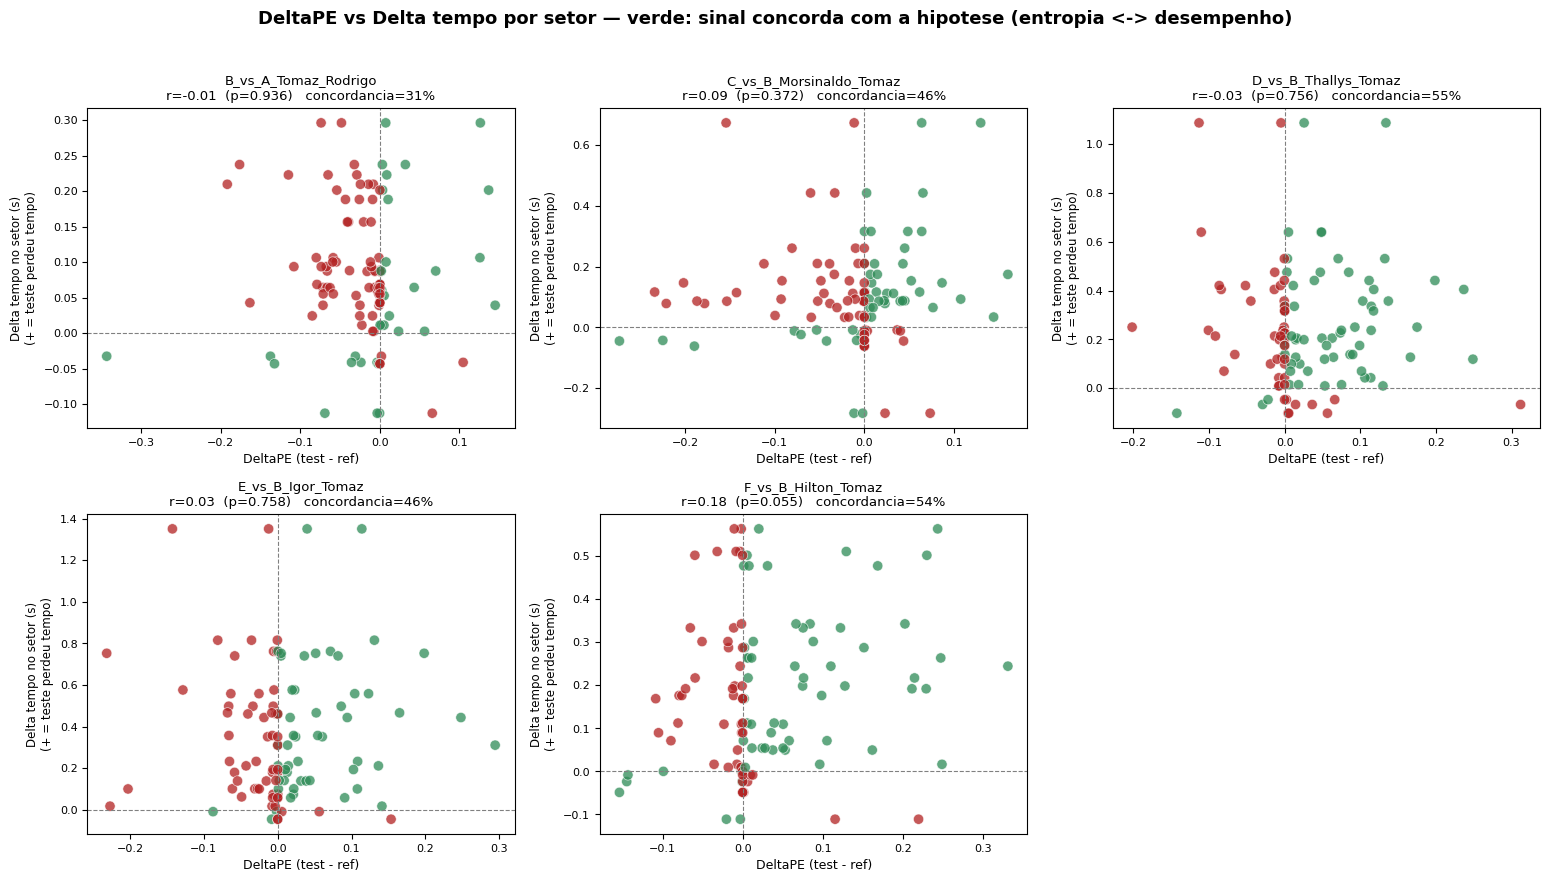

In [16]:
def plot_deltaPE_vs_deltatime_by_comparison(df_sign_agree, save_dir):
    """Um painel por comparacao: DeltaPE (x) vs DeltaTime_s (y), verde = sinais
    concordam com a hipotese (mais entropia -> mais tempo perdido), vermelho = discordam."""
    if df_sign_agree.empty:
        return
    save_dir.mkdir(parents=True, exist_ok=True)

    comparisons = [c['id'] for c in SKILL_COMPARISONS if c['id'] in df_sign_agree['Comparison'].unique()]
    ncols = 3
    nrows = int(np.ceil(len(comparisons) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.3 * nrows), squeeze=False)

    for i, comp_id in enumerate(comparisons):
        ax  = axes[i // ncols][i % ncols]
        sub = df_sign_agree[df_sign_agree['Comparison'] == comp_id]
        colors = sub['sign_agree'].map({True: 'seagreen', False: 'firebrick'})
        ax.scatter(sub['DeltaPE'], sub['DeltaTime_s'], c=colors, alpha=0.75,
                   edgecolor='white', s=55, linewidth=0.5)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=0.8, ls='--')

        title = comp_id
        if len(sub) >= 4:
            r, p = pearsonr(sub['DeltaPE'], sub['DeltaTime_s'])
            title += f"\nr={r:.2f}  (p={p:.3f})   concordancia={sub['sign_agree'].mean():.0%}"
        ax.set_title(title, fontsize=9.5)
        ax.set_xlabel('DeltaPE (test - ref)', fontsize=9)
        ax.set_ylabel('Delta tempo no setor (s)\n(+ = teste perdeu tempo)', fontsize=8.5)
        ax.tick_params(labelsize=8)

    for j in range(len(comparisons), nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    fig.suptitle('DeltaPE vs Delta tempo por setor — verde: sinal concorda com a hipotese '
                 '(entropia <-> desempenho)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(save_dir / 'deltaPE_vs_deltatime_by_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()


plot_deltaPE_vs_deltatime_by_comparison(df_sign_agree, BATCH_SAVE_ROOT / 'sign_agreement')


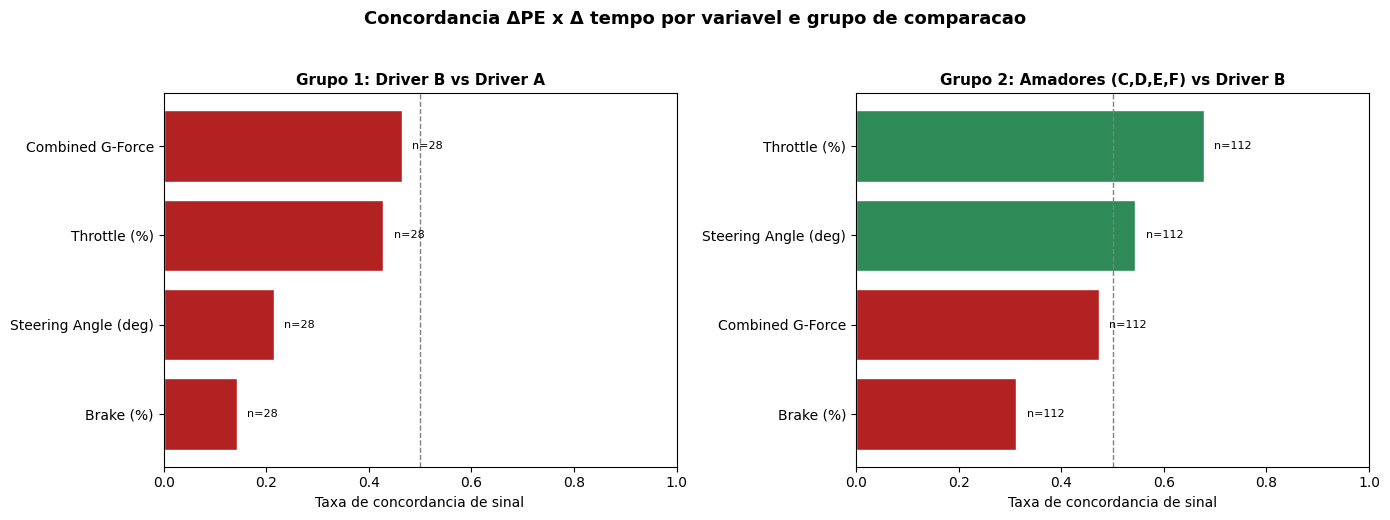

  INSIGHT AUTOMATICO
Concordancia global de sinal entre DeltaPE e Delta tempo por setor: 46.4%.
Isso NAO suporta a hipotese de que maior entropia de permutacao (maior aleatoriedade
no controle) coincide com perda de tempo no setor (e menor PE com ganho de tempo).

  - Grupo 1: Driver B vs Driver A: 31.2% de concordancia -> NAO suporta a hipotese.
  - Grupo 2: Amadores (C,D,E,F) vs Driver B: 50.2% de concordancia -> suporta a hipotese.


In [17]:
def plot_hit_rate_summary(df_sign_agree, save_dir):
    """Barras de taxa de concordancia por Variavel, separadas por Grupo."""
    if df_sign_agree.empty:
        return
    save_dir.mkdir(parents=True, exist_ok=True)

    summary = (df_sign_agree.groupby(['Group', 'Variable'])['sign_agree']
               .agg(['mean', 'count']).reset_index()
               .rename(columns={'mean': 'hit_rate', 'count': 'n_pairs'}))

    groups   = summary['Group'].unique()
    fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5), squeeze=False)
    axes = axes[0]

    for ax, grp in zip(axes, groups):
        sub = summary[summary['Group'] == grp].sort_values('hit_rate')
        colors = ['seagreen' if h >= 0.5 else 'firebrick' for h in sub['hit_rate']]
        ax.barh(sub['Variable'], sub['hit_rate'], color=colors, edgecolor='white')
        ax.axvline(0.5, color='gray', ls='--', lw=1)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Taxa de concordancia de sinal')
        ax.set_title(grp, fontsize=11, fontweight='bold')
        for y, (h, n) in enumerate(zip(sub['hit_rate'], sub['n_pairs'])):
            ax.text(h + 0.02, y, f"n={n}", va='center', fontsize=8)

    fig.suptitle('Concordancia ΔPE x Δ tempo por variavel e grupo de comparacao',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    fig.savefig(save_dir / 'hit_rate_summary_by_variable.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    return summary


df_hit_rate_summary = plot_hit_rate_summary(df_sign_agree, BATCH_SAVE_ROOT / 'sign_agreement')

# ── Interpretacao automatica (para colar no Results/Discussion) ─────────────
if not df_sign_agree.empty:
    overall = df_sign_agree['sign_agree'].mean()
    by_group = df_sign_agree.groupby('Group')['sign_agree'].mean()

    print("=" * 90)
    print("  INSIGHT AUTOMATICO")
    print("=" * 90)
    veredito = "suporta" if overall > 0.5 else "NAO suporta"
    print(f"Concordancia global de sinal entre DeltaPE e Delta tempo por setor: {overall:.1%}.")
    print(f"Isso {veredito} a hipotese de que maior entropia de permutacao (maior aleatoriedade\n"
          f"no controle) coincide com perda de tempo no setor (e menor PE com ganho de tempo).\n")
    for grp, val in by_group.items():
        veredito_g = "suporta" if val > 0.5 else "NAO suporta"
        print(f"  - {grp}: {val:.1%} de concordancia -> {veredito_g} a hipotese.")


In [18]:
from itertools import product
from scipy.stats import norm

# ── Permutação por comparação (nível setor) ─────────────────────────────────
def permutation_test_correlation(x, y, n_perm=10000, random_state=42):
    """
    H0: nao ha correspondencia real entre DeltaPE e Delta tempo por setor,
    dentro da mesma comparacao. Embaralha y em relacao a x N vezes.
    Nao assume normalidade; NAO remove autocorrelacao espacial entre
    setores adjacentes (limitacao a reportar, sobretudo no Grupo 1).
    """
    rng = np.random.default_rng(random_state)
    x, y = np.asarray(x), np.asarray(y)
    if len(x) < 4:
        return np.nan, np.nan, len(x)
    r_obs, _ = pearsonr(x, y)
    null_r = np.array([pearsonr(x, rng.permutation(y))[0] for _ in range(n_perm)])
    p_perm = (np.sum(np.abs(null_r) >= np.abs(r_obs)) + 1) / (n_perm + 1)
    return r_obs, p_perm, len(x)


def permutation_test_hit_rate(sign_pe, sign_time, n_perm=10000, random_state=42):
    """Mesma logica, para a taxa de concordancia de sinal (sign_agree)."""
    rng = np.random.default_rng(random_state)
    sign_pe, sign_time = np.asarray(sign_pe), np.asarray(sign_time)
    n = len(sign_pe)
    if n < 4:
        return np.nan, np.nan, n
    hit_obs = np.mean(sign_pe == sign_time)
    null_hit = np.array([np.mean(sign_pe == rng.permutation(sign_time)) for _ in range(n_perm)])
    p_perm = (np.sum(np.abs(null_hit - 0.5) >= np.abs(hit_obs - 0.5)) + 1) / (n_perm + 1)
    return hit_obs, p_perm, n


perm_rows = []
for comp_id, sub in df_sign_agree.groupby('Comparison'):
    r_obs, p_r, n = permutation_test_correlation(sub['DeltaPE'], sub['DeltaTime_s'])
    hit_obs, p_hit, _ = permutation_test_hit_rate(sub['sign_PE'], sub['sign_Time'])
    perm_rows.append({'Comparison': comp_id, 'Group': COMPARISON_GROUP.get(comp_id, comp_id),
                       'n_pairs': n, 'r_obs': r_obs, 'p_perm_r': p_r,
                       'hit_rate_obs': hit_obs, 'p_perm_hit': p_hit})

df_perm = pd.DataFrame(perm_rows)
df_perm = apply_fdr(df_perm, pcol='p_perm_r')
df_perm.rename(columns={'p-adj (FDR)': 'p_perm_r_FDR', 'sig (FDR)': 'sig_r_FDR'}, inplace=True)
display(df_perm)

,Comparison,Group,n_pairs,r_obs,p_perm_r,hit_rate_obs,p_perm_hit,p_perm_r_FDR,sig_r_FDR
0,B_vs_A_Tomaz_Rodrigo,Grupo 1: Driver B vs Driver A,112,-0.007660,0.931407,0.312500,0.770223,0.931407,False
1,C_vs_B_Morsinaldo_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",112,0.085130,0.368263,0.455357,0.840716,0.920658,False
2,D_vs_B_Thallys_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",112,-0.029668,0.758724,0.553571,0.728027,0.931407,False
3,E_vs_B_Igor_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",112,0.029378,0.754725,0.464286,0.609639,0.931407,False
4,F_vs_B_Hilton_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",112,0.181645,0.057994,0.535714,0.373263,0.289971,False


In [19]:
# ── Meta-analise (Fisher-z) — SO valida quando ha >1 comparacao independente ─
def fisher_z_meta(rs, ns):
    """
    Combina correlacoes de comparacoes INDEPENDENTES (uma por par ref/test).
    Nao usar com setores soltos - a unidade aqui e a comparacao inteira.
    """
    rs, ns = np.asarray(rs, dtype=float), np.asarray(ns, dtype=float)
    mask = np.isfinite(rs) & (ns > 3)
    rs, ns = rs[mask], ns[mask]
    k = len(rs)
    if k < 2:
        return {'k_comparisons': k, 'r_meta': np.nan, 'p_meta': np.nan}
    z = np.arctanh(rs); w = ns - 3
    z_bar = np.sum(w * z) / np.sum(w)
    z_stat = z_bar / (1 / np.sqrt(np.sum(w)))
    return {'k_comparisons': k, 'r_meta': np.tanh(z_bar),
            'z_stat': z_stat, 'p_meta': 2 * (1 - norm.cdf(abs(z_stat)))}


group2_ids = [c for c, g in COMPARISON_GROUP.items() if g.startswith('Grupo 2')]
sub2 = df_perm[df_perm['Comparison'].isin(group2_ids)]
meta_group2 = fisher_z_meta(sub2['r_obs'], sub2['n_pairs'])

print(f"Grupo 2 — meta-analise Fisher-z: k={meta_group2['k_comparisons']} comparacoes, "
      f"r_meta={meta_group2['r_meta']:.3f}, p={meta_group2['p_meta']:.4f}")
print("Grupo 1 — apenas 1 comparacao: meta-analise entre comparacoes NAO se aplica; "
      "reportar somente o p de permutacao dentro da comparacao (tabela acima), como exploratorio.")

Grupo 2 — meta-analise Fisher-z: k=4 comparacoes, r_meta=0.067, p=0.1607
Grupo 1 — apenas 1 comparacao: meta-analise entre comparacoes NAO se aplica; reportar somente o p de permutacao dentro da comparacao (tabela acima), como exploratorio.


In [20]:
# ── Teste exato (enumeracao completa) — apropriado para k pequeno (Grupo 2, k=4) ──
def exact_cluster_sign_test(comparison_ids, df_perm):
    """
    Enumera TODAS as 2^k combinacoes de sinal das taxas de concordancia por
    comparacao (k=4 -> 16 permutacoes), sem aproximacao Monte Carlo.
    Nota: com k=4, o menor p bilateral possivel e 2/16 = 0.125 - limite
    estrutural do desenho (poucas comparacoes independentes), nao um erro.
    """
    rates = df_perm.loc[df_perm['Comparison'].isin(comparison_ids), 'hit_rate_obs'].values
    k = len(rates)
    obs_stat = np.mean(rates) - 0.5
    null_stats = np.array([np.mean(0.5 + np.array(flips) * (rates - 0.5)) - 0.5
                            for flips in product([1, -1], repeat=k)])
    p_exact = np.mean(np.abs(null_stats) >= abs(obs_stat))
    return {'k': k, 'mean_hit_rate': np.mean(rates), 'p_exact': p_exact,
            'n_permutations': len(null_stats)}


exact_result = exact_cluster_sign_test(group2_ids, df_perm)
print(f"Grupo 2 — teste exato: k={exact_result['k']}, 2^k={exact_result['n_permutations']} "
      f"permutacoes, taxa media={exact_result['mean_hit_rate']:.1%}, "
      f"p exato={exact_result['p_exact']:.4f}")

Grupo 2 — teste exato: k=4, 2^k=16 permutacoes, taxa media=50.2%, p exato=1.0000


In [21]:
# ── Célula A: permutação por Comparacao x Variavel (granularidade fina) ─────
perm_var_rows = []
for (comp_id, variable), sub in df_sign_agree.groupby(['Comparison', 'Variable']):
    r_obs, p_r, n = permutation_test_correlation(sub['DeltaPE'], sub['DeltaTime_s'])
    hit_obs, p_hit, _ = permutation_test_hit_rate(sub['sign_PE'], sub['sign_Time'])
    perm_var_rows.append({
        'Comparison': comp_id,
        'Group': COMPARISON_GROUP.get(comp_id, comp_id),
        'Variable': variable,
        'n_pairs': n,
        'r_obs': r_obs,
        'p_perm_r': p_r,
        'hit_rate_obs': hit_obs,
        'p_perm_hit': p_hit,
    })

df_perm_var = pd.DataFrame(perm_var_rows)
df_perm_var = apply_fdr(df_perm_var, pcol='p_perm_r')
df_perm_var.rename(columns={'p-adj (FDR)': 'p_perm_r_FDR', 'sig (FDR)': 'sig_r_FDR'}, inplace=True)

print("Permutacao por Comparacao x Variavel:")
display(df_perm_var.sort_values(['Variable', 'Comparison']))

Permutacao por Comparacao x Variavel:


,Comparison,Group,Variable,n_pairs,r_obs,p_perm_r,hit_rate_obs,p_perm_hit,p_perm_r_FDR,sig_r_FDR
0,B_vs_A_Tomaz_Rodrigo,Grupo 1: Driver B vs Driver A,Brake (%),28,-0.310958,0.110389,0.142857,0.130487,0.501950,False
4,C_vs_B_Morsinaldo_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Brake (%),28,-0.167151,0.361664,0.250000,0.555244,0.724328,False
8,D_vs_B_Thallys_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Brake (%),28,-0.206834,0.280072,0.250000,0.135586,0.700180,False
12,E_vs_B_Igor_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Brake (%),28,-0.137887,0.475052,0.250000,0.262974,0.783306,False
16,F_vs_B_Hilton_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Brake (%),28,-0.130614,0.509149,0.500000,1.000000,0.783306,False
1,B_vs_A_Tomaz_Rodrigo,Grupo 1: Driver B vs Driver A,Combined G-Force,28,0.071095,0.722228,0.464286,1.000000,0.908709,False
5,C_vs_B_Morsinaldo_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Combined G-Force,28,-0.053853,0.785021,0.642857,0.256474,0.908709,False
9,D_vs_B_Thallys_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Combined G-Force,28,0.135101,0.476652,0.428571,0.445155,0.783306,False
13,E_vs_B_Igor_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Combined G-Force,28,0.023001,0.908709,0.357143,1.000000,0.908709,False
17,F_vs_B_Hilton_Tomaz,"Grupo 2: Amadores (C,D,E,F) vs Driver B",Combined G-Force,28,-0.032365,0.869213,0.464286,1.000000,0.908709,False


In [22]:
# ── Célula B: meta-analise Fisher-z + teste exato, POR VARIAVEL, so Grupo 2 ─
def exact_cluster_sign_test_var(comparison_ids, df, variable):
    """Mesmo teste exato de antes, mas filtrado para uma unica variavel."""
    rates = df.loc[(df['Comparison'].isin(comparison_ids)) & (df['Variable'] == variable),
                    'hit_rate_obs'].values
    k = len(rates)
    if k < 2:
        return {'k': k, 'mean_hit_rate': np.nan, 'p_exact': np.nan, 'n_permutations': 0}
    obs_stat = np.mean(rates) - 0.5
    null_stats = np.array([np.mean(0.5 + np.array(flips) * (rates - 0.5)) - 0.5
                            for flips in product([1, -1], repeat=k)])
    p_exact = np.mean(np.abs(null_stats) >= abs(obs_stat))
    return {'k': k, 'mean_hit_rate': np.mean(rates), 'p_exact': p_exact,
            'n_permutations': len(null_stats)}


variables = df_perm_var['Variable'].unique()
summary_rows = []

for variable in variables:
    sub_var = df_perm_var[(df_perm_var['Comparison'].isin(group2_ids)) &
                           (df_perm_var['Variable'] == variable)]
    meta_v = fisher_z_meta(sub_var['r_obs'], sub_var['n_pairs'])
    exact_v = exact_cluster_sign_test_var(group2_ids, df_perm_var, variable)
    summary_rows.append({
        'Variable': variable,
        'k_comparisons': meta_v['k_comparisons'],
        'r_meta': meta_v['r_meta'],
        'p_meta': meta_v.get('p_meta', np.nan),
        'mean_hit_rate': exact_v['mean_hit_rate'],
        'p_exact': exact_v['p_exact'],
    })

df_summary_by_variable = pd.DataFrame(summary_rows)
df_summary_by_variable = apply_fdr(df_summary_by_variable, pcol='p_meta')
df_summary_by_variable.rename(columns={'p-adj (FDR)': 'p_meta_FDR', 'sig (FDR)': 'sig_meta_FDR'},
                               inplace=True)

print("=" * 90)
print("  GRUPO 2 (amadores vs Driver B) — meta-analise e teste exato, POR VARIAVEL")
print("=" * 90)
display(df_summary_by_variable)

  GRUPO 2 (amadores vs Driver B) — meta-analise e teste exato, POR VARIAVEL


,Variable,k_comparisons,r_meta,p_meta,mean_hit_rate,p_exact,p_meta_FDR,sig_meta_FDR
0,Brake (%),4,-0.160775,0.104841,0.312500,0.2500,0.139788,False
1,Combined G-Force,4,0.018162,0.855865,0.473214,0.6875,0.855865,False
2,Steering Angle (deg),4,0.216505,0.027817,0.544643,1.0000,0.055634,False
3,Throttle (%),4,0.253980,0.009414,0.678571,0.2500,0.037658,True
